# PHÂN TÍCH DỮ LIỆU KHÁCH HÀNG NGÂN HÀNG - PHÂN CỤM VÀ DỰ BÁO MỞ THẺ TÍN DỤNG

**Mục tiêu:**
1. Phân cụm khách hàng dựa trên hành vi giao dịch, hoạt động app, cho vay, tiền gửi
2. Dự báo khả năng mở thẻ tín dụng của khách hàng
3. So sánh hiệu quả các thuật toán ML

**Cấu trúc notebook:**
- Phần 1: Thiết lập & Import thư viện
- Phần 2: Đọc & Khám phá dữ liệu
- Phần 3: Feature Engineering (Tạo đặc trưng)
- Phần 4: Phân cụm khách hàng (Clustering)
- Phần 5: Trực quan hóa Clustering
- Phần 6: Dự báo mở thẻ tín dụng (Classification)
- Phần 7: Mô hình phân loại - Baseline
- Phần 8: Mô hình phân loại - Nâng cao
- Phần 9: Xử lý mất cân bằng dữ liệu
- Phần 10: Tổng kết & Lưu mô hình

---
## PHẦN 1: THIẾT LẬP & IMPORT THƯ VIỆN
Import tất cả các thư viện cần thiết cho phân tích

In [7]:
# Thư viện xử lý dữ liệu cơ bản
import pandas as pd  # Xử lý dữ liệu dạng bảng
import numpy as np   # Tính toán số học

# Thư viện trực quan hóa
import matplotlib.pyplot as plt  # Vẽ biểu đồ cơ bản
import seaborn as sns           # Vẽ biểu đồ thống kê đẹp mắt

# Thư viện tiền xử lý dữ liệu
from sklearn.preprocessing import StandardScaler  # Chuẩn hóa dữ liệu
from sklearn.impute import SimpleImputer          # Xử lý giá trị thiếu

# Thư viện phân cụm (Clustering)
from sklearn.cluster import KMeans, MiniBatchKMeans  # Thuật toán K-Means
from sklearn.metrics import silhouette_score          # Đánh giá chất lượng cluster
from sklearn.decomposition import PCA                 # Giảm chiều dữ liệu

# Thư viện phân loại (Classification)
from sklearn.model_selection import train_test_split  # Chia tập train/test
from sklearn.linear_model import LogisticRegression   # Hồi quy Logistic
from sklearn.ensemble import RandomForestClassifier   # Random Forest
from xgboost import XGBClassifier                     # XGBoost

# Thư viện xây dựng pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Thư viện đánh giá mô hình
from sklearn.metrics import (
    roc_auc_score,              # ROC-AUC score
    average_precision_score,     # PR-AUC score
    classification_report,       # Báo cáo phân loại
    confusion_matrix            # Ma trận nhầm lẫn
)
from sklearn.inspection import permutation_importance  # Feature importance

# Thư viện xử lý mất cân bằng dữ liệu
from imblearn.over_sampling import RandomOverSampler, BorderlineSMOTE, ADASYN

# Thư viện thống kê
from scipy.stats import chi2_contingency  # Kiểm định Chi-square

# Thư viện lưu/load mô hình
import joblib

# Cài đặt hiển thị
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Đã import thành công tất cả thư viện!")

✅ Đã import thành công tất cả thư viện!


---
## PHẦN 2: ĐỌC & KHÁM PHÁ DỮ LIỆU

### 2.1. Đọc dữ liệu từ các file
Đọc 5 bảng dữ liệu chính:
- **Customer**: Thông tin khách hàng
- **Transaction**: Giao dịch của khách hàng
- **Activity**: Hoạt động trên app MyVIB
- **Deposit**: Thông tin tiền gửi
- **Lending**: Thông tin cho vay

In [8]:
# Đọc dữ liệu khách hàng
df_customer = pd.read_csv('data/Data_Customer.csv', low_memory=False)
print(f"✅ Customer: {df_customer.shape[0]:,} dòng, {df_customer.shape[1]} cột")

# Đọc dữ liệu giao dịch
df_tx = pd.read_csv('data/Data_MyVIB_Transaction.csv')
print(f"✅ Transaction: {df_tx.shape[0]:,} dòng, {df_tx.shape[1]} cột")

# Đọc dữ liệu hoạt động app
df_act = pd.read_csv('data/Data_MyVIB_Activity.csv')
print(f"✅ Activity: {df_act.shape[0]:,} dòng, {df_act.shape[1]} cột")

# Đọc dữ liệu tiền gửi
df_dep = pd.read_csv('data/Data_Deposit.csv')
print(f"✅ Deposit: {df_dep.shape[0]:,} dòng, {df_dep.shape[1]} cột")

# Đọc dữ liệu cho vay (Excel)
df_loan = pd.read_excel('data/Data_Lending.xlsx')
print(f"✅ Lending: {df_loan.shape[0]:,} dòng, {df_loan.shape[1]} cột")

✅ Customer: 290,223 dòng, 9 cột
✅ Transaction: 1,418,030 dòng, 8 cột
✅ Activity: 16,132,675 dòng, 6 cột
✅ Deposit: 1,258,424 dòng, 6 cột


d:\DATN1\venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
d:\DATN1\venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


✅ Lending: 576,431 dòng, 4 cột


### 2.2. Khám phá dữ liệu từng bảng

In [9]:
# Xem dữ liệu Customer
print("=== DỮ LIỆU KHÁCH HÀNG ===")
display(df_customer.head())
print(f"Số khách hàng duy nhất: {df_customer['CUSTOMER_NUMBER'].nunique():,}")

=== DỮ LIỆU KHÁCH HÀNG ===


,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF_VIB,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
0,639362,M,2019-04-23,1996-01-01 00:00:00,N,2019-04-23,BRANCH,Y,SMS
1,452440,M,2019-01-11,1999-10-10 00:00:00,N,2019-01-11,BRANCH,Y,SMART_OTP
2,326290,F,2019-05-27,1996-06-29 00:00:00,N,2019-05-27,BRANCH,Y,SMS
3,20802,M,2019-11-12,1992-08-07 00:00:00,N,2019-11-12,BRANCH,Y,SMART_OTP
4,114244,M,2019-03-29,1973-10-15 00:00:00,N,2019-03-29,BRANCH,N,SMS


Số khách hàng duy nhất: 290,223


In [ ]:
# Tạo bảng demographic + digital banking registration/auth features

df_demographic = df_customer[[
    'CUSTOMER_NUMBER',
    'CLIENT_SEX',
    'DATE_OF_BIRTH',
    'STAFF_VIB',
    'SMS',
    'VERIFY_METHOD',
    'EB_REGISTER_CHANNEL'
]].copy()

# 1. Gender: Chuyển M/F thành 1/0 + cờ missing
df_demographic['gender_male'] = (df_demographic['CLIENT_SEX'] == 'M').astype(int)
df_demographic['gender_unknown'] = df_demographic['CLIENT_SEX'].isna().astype(int)

# 2. Age: Tính tuổi từ ngày sinh + cờ missing
current_year = 2026  # Năm hiện tại trong dữ liệu

# Parse DATE_OF_BIRTH
df_demographic['DATE_OF_BIRTH'] = pd.to_datetime(df_demographic['DATE_OF_BIRTH'], errors='coerce')
df_demographic['birth_year'] = df_demographic['DATE_OF_BIRTH'].dt.year
df_demographic['age'] = current_year - df_demographic['birth_year']

# Xử lý tuổi bất thường (< 18 hoặc > 100)
invalid_age = (df_demographic['age'] < 18) | (df_demographic['age'] > 100) | df_demographic['age'].isna()
df_demographic['age_missing'] = invalid_age.astype(int)
df_demographic.loc[invalid_age, 'age'] = 0

# 3. Age Group: Phân nhóm tuổi (Unknown khi age=0)
def get_age_group(age):
    if pd.isna(age) or age == 0:
        return 'Unknown'
    elif age < 25:
        return 'Gen Z (18-24)'
    elif age < 40:
        return 'Millennials (25-39)'
    elif age < 55:
        return 'Gen X (40-54)'
    else:
        return 'Boomers (55+)'

df_demographic['age_group'] = df_demographic['age'].apply(get_age_group)

# Tạo dummy variables cho age_group
age_dummies = pd.get_dummies(df_demographic['age_group'], prefix='age')
expected_age = [
    'age_Gen Z (18-24)',
    'age_Millennials (25-39)',
    'age_Gen X (40-54)',
    'age_Boomers (55+)',
    'age_Unknown'
]
for col in expected_age:
    if col not in age_dummies.columns:
        age_dummies[col] = 0

# 4. Staff: Chuyển Y/N thành 1/0
df_demographic['is_staff'] = (df_demographic['STAFF_VIB'] == 'Y').astype(int)

# 5. Auth/Registration features từ Customer table
# SMS opt-in + unknown
sms_opt_in = (df_demographic['SMS'] == 'Y').astype(int).rename('sms_opt_in')
sms_unknown = df_demographic['SMS'].isna().astype(int).rename('sms_unknown')

# VERIFY_METHOD dummies + unknown
verify_dummies = pd.get_dummies(df_demographic['VERIFY_METHOD'], prefix='verify')
expected_verify = ['verify_HARD_TOKEN', 'verify_SMS', 'verify_SMART_OTP', 'verify_UNKNOWN']
if 'verify_UNKNOWN' not in verify_dummies.columns:
    verify_dummies['verify_UNKNOWN'] = df_demographic['VERIFY_METHOD'].isna().astype(int)
for col in expected_verify:
    if col not in verify_dummies.columns:
        verify_dummies[col] = 0

# EB_REGISTER_CHANNEL dummies + unknown
channel_dummies = pd.get_dummies(df_demographic['EB_REGISTER_CHANNEL'], prefix='channel')
channel_dummies.columns = channel_dummies.columns.str.replace('-', '_', regex=False)
expected_channel = ['channel_BRANCH', 'channel_AUTO_JOB', 'channel_MYVIB', 'channel_WEBSITE', 'channel_UNKNOWN']
if 'channel_UNKNOWN' not in channel_dummies.columns:
    channel_dummies['channel_UNKNOWN'] = df_demographic['EB_REGISTER_CHANNEL'].isna().astype(int)
for col in expected_channel:
    if col not in channel_dummies.columns:
        channel_dummies[col] = 0

# 6. Merge dummy variables vào df_demographic
df_demographic = pd.concat([
    df_demographic,
    age_dummies,
    verify_dummies,
    channel_dummies,
    sms_opt_in,
    sms_unknown
], axis=1)

# Giữ lại các cột cần thiết
base_columns = [
    'CUSTOMER_NUMBER',
    'gender_male',
    'gender_unknown',
    'age',
    'age_missing',
    'age_Gen Z (18-24)',
    'age_Millennials (25-39)',
    'age_Gen X (40-54)',
    'age_Boomers (55+)',
    'age_Unknown',
    'is_staff',
    'sms_opt_in',
    'sms_unknown'
]

demographic_features = df_demographic[base_columns].copy()

# Thêm dummies nếu có
for col in expected_verify:
    demographic_features[col] = df_demographic[col]
for col in expected_channel:
    demographic_features[col] = df_demographic[col]

# Điền giá trị null = 0
demographic_features.fillna(0, inplace=True)

print(f"✅ Đã tạo {len(demographic_features)} dòng đặc trưng Demographics + Digital (Unknown-aware)")
print(f"\nPhân bố giới tính:")
print(f"  - Nam (M): {df_demographic['gender_male'].sum():,} ({df_demographic['gender_male'].mean()*100:.1f}%)")
print(f"  - Nữ (F): {(df_demographic['gender_male']==0).sum():,} ({(1-df_demographic['gender_male'].mean())*100:.1f}%)")
print(f"  - Unknown: {df_demographic['gender_unknown'].sum():,}")

print(f"\nPhân bố nhóm tuổi:")
print(df_demographic['age_group'].value_counts())

print(f"\nPhân bố nhân viên:")
print(f"  - Là nhân viên (Y): {demographic_features['is_staff'].sum():,} ({demographic_features['is_staff'].mean()*100:.2f}%)")
print(f"  - Không phải nhân viên (N): {(demographic_features['is_staff']==0).sum():,}")

display(demographic_features.head())

### 2.3. Xử lý đặc trưng Nhân khẩu học (Demographics)
Tạo các features từ dữ liệu nhân khẩu học:
- **Giới tính**: Male (1) / Female (0)
- **Tuổi**: Tính từ ngày sinh
- **Nhóm tuổi**: Gen Z, Millennials, Gen X, Boomers
- **Nhân viên ngân hàng**: Có (1) / Không (0)

In [10]:
# Xem dữ liệu Transaction
print("=== DỮ LIỆU GIAO DỊCH ===")
display(df_tx.head())
print(f"\nCác loại giao dịch:")
print(df_tx['TRANS_LV1'].value_counts())

=== DỮ LIỆU GIAO DỊCH ===


,TRANS_LV1,TRANS_LV2,TRANS_DATE,DAY_OF_WEEK,TRANS_HOUR,TRANS_NO,TRANS_AMOUNT,CUSTOMER_NUMBER
0,Transfer,Outside_VIB,2019-01-03,Thu,17,2,189771864.0,701619
1,Transfer,Outside_VIB,2019-07-01,Mon,13,2,30224900.0,701619
2,Transfer,Outside_VIB,2019-01-02,Wed,15,1,100000.0,701619
3,Payment,Credit_card_repayment,2019-01-03,Thu,14,1,85000000.0,262123
4,Payment,Credit_card_repayment,2019-01-28,Mon,22,1,83000000.0,262123



Các loại giao dịch:
TRANS_LV1
Transfer    989851
Topup       348766
Payment      79413
Name: count, dtype: int64


In [11]:
# Xem dữ liệu Activity
print("=== DỮ LIỆU HOẠT ĐỘNG APP ===")
display(df_act.head())
print(f"\nTop 20 hoạt động phổ biến:")
df_act["ACTIVITY_NAME"] = df_act["ACTIVITY_NAME"].astype(str)
print(df_act["ACTIVITY_NAME"].value_counts().head(20))

=== DỮ LIỆU HOẠT ĐỘNG APP ===


,ACTIVITY_DATE,DAY_OF_WEEK,ACTIVITY_HOUR,ACTIVITY_NO,CUSTOMER_NUMBER,ACTIVITY_NAME
0,1/22/2019,Tue,20,2,630178,MB_INTEREST_RATE_VIEW
1,1/10/2019,Thu,18,16,630178,MB_INTEREST_RATE_VIEW
2,1/26/2019,Sat,17,15,630178,MB_INTEREST_RATE_VIEW
3,1/2/2019,Wed,9,27,630178,MB_INTEREST_RATE_VIEW
4,1/19/2019,Sat,8,3,630178,MB_INTEREST_RATE_VIEW



Top 20 hoạt động phổ biến:
ACTIVITY_NAME
LOGIN                          3638224
LOGOUT                         3499251
QUERY_ACCOUNT_INFORMATION      2566128
MB_INTEREST_RATE_VIEW          2448877
TRANSACTION_OVERVIEW_QUERY     1079162
LOGIN_FINGER                    784355
TRANSFER_VIA_SML                679219
LOGIN_FACEID                    237933
TRANSFER_VIB_ACCOUNT            216639
TOPUP_MOBILE                    206441
MB_LOCATION_POS_VIEW            184072
MB_ACCOUNT_QUICK_BALANCE        170850
AUTHENTICATION                  144475
MB_SET_PIN                       69744
MB_BILLPAY                       34703
TRANSFER_VIA_PAYMENT_CENTER      31443
MB_LOCATION_BRANCH_VIEW          28239
CHANGE_PASSWORD                  26410
TRANSFER_VIA_SML_ACCOUNT         20358
MB_LOCATION_ATM_VIEW             17996
Name: count, dtype: int64


In [12]:
# Xem dữ liệu Deposit
print("=== DỮ LIỆU TIỀN GỬI ===")
display(df_dep.head())
print(f"\nCột: {df_dep.columns.tolist()}")

=== DỮ LIỆU TIỀN GỬI ===


,MONTH,COUNT_CA_ACCT,AVG_CA_BALANCE,COUNT_TD_ACCT,AVG_TD_BALANCE,CUSTOMER_NUMBER
0,1/31/2019,1,246774.19,0,0.0,914393
1,2/28/2019,1,209207.36,0,0.0,914393
2,3/31/2019,1,213225.90,0,0.0,914393
3,4/30/2019,1,211761.87,0,0.0,914393
4,5/31/2019,1,222391.16,0,0.0,914393



Cột: ['MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'CUSTOMER_NUMBER']


In [13]:
# Xem dữ liệu Lending
print("=== DỮ LIỆU CHO VAY ===")
display(df_loan.head())

=== DỮ LIỆU CHO VAY ===


,MONTH,COUNT_OF_LOAN,AVG_LOAN_AMOUNT,CUSTOMER_NUMBER
0,2019-07-31,1,285166000.0,7
1,2019-08-31,1,280332000.0,7
2,2019-09-30,1,275498000.0,7
3,2019-10-31,1,270664000.0,7
4,2019-11-30,1,265830000.0,7


---
## PHẦN 3: FEATURE ENGINEERING (TẠO ĐẶC TRƯNG)

### 3.1. Tạo đặc trưng từ Transaction (Giao dịch)
Tạo các chỉ số tổng hợp từ dữ liệu giao dịch cho mỗi khách hàng:
- Tổng số giao dịch
- Tổng giá trị giao dịch
- Số giao dịch Transfer
- Số giao dịch Payment

In [ ]:
# Tạo đặc trưng tổng hợp từ Transaction
# Lưu y: dùng TRANS_LV2 để tách chuyển khoản nội bộ/ngoài hệ thống và nhóm thanh toán chi tiết

is_transfer_lv1 = df_tx["TRANS_LV1"] == "Transfer"

tx_agg = (
    df_tx
    .assign(is_transfer_lv1=is_transfer_lv1)
    .groupby("CUSTOMER_NUMBER")
    .agg(
        tx_cnt=("TRANS_NO", "count"),                               # Tổng số giao dịch
        tx_amount=("TRANS_AMOUNT", "sum"),                          # Tổng giá trị giao dịch
        transfer_cnt=("TRANS_LV1", lambda x: (x == "Transfer").sum()),  # Số giao dịch chuyển tiền
        payment_cnt=("TRANS_LV1", lambda x: (x == "Payment").sum()),     # Số giao dịch thanh toán

        # Tách chuyển khoản nội bộ/ngoài hệ thống (chỉ tính giao dịch Transfer)
        transfer_within_vib_cnt=("TRANS_LV2", lambda x: ((x == "Within_VIB") & is_transfer_lv1.loc[x.index]).sum()),
        transfer_outside_vib_cnt=("TRANS_LV2", lambda x: ((x == "Outside_VIB") & is_transfer_lv1.loc[x.index]).sum()),

        # Thanh toán hóa đơn theo loại (từ TRANS_LV2)
        payment_utility_cnt=("TRANS_LV2", lambda x: (x == "Utilities_payment").sum()),
        payment_insurance_cnt=("TRANS_LV2", lambda x: (x == "Insurance_payment").sum()),
        payment_cable_cnt=("TRANS_LV2", lambda x: (x == "Cable").sum()),
        payment_game_cnt=("TRANS_LV2", lambda x: (x == "Game").sum()),
        payment_lifestyle_cnt=("TRANS_LV2", lambda x: (x == "Lifestyle_payment").sum()),
        payment_qr_cnt=("TRANS_LV2", lambda x: (x == "QR_payment").sum()),
        credit_card_repayment_cnt=("TRANS_LV2", lambda x: (x == "Credit_card_repayment").sum()),
        lending_repayment_cnt=("TRANS_LV2", lambda x: (x == "Lending_repayment").sum()),

        # Nạp tiền ví điện tử (eWallet)
        ewallet_topup_cnt=("TRANS_LV2", lambda x: (x == "eWallet").sum()),
    )
    .reset_index()
)

print(f"✅ Đã tạo {len(tx_agg)} dòng đặc trưng Transaction")
display(tx_agg.head())
display(tx_agg.describe())

✅ Đã tạo 52488 dòng đặc trưng Transaction


,CUSTOMER_NUMBER,tx_cnt,tx_amount,transfer_cnt,payment_cnt
0,0,10,249819000.0,10,0
1,9,6,11694976.0,2,1
2,15,3,51400000.0,3,0
3,32,32,22550050.0,17,0
4,44,3,25000000.0,3,0


,CUSTOMER_NUMBER,tx_cnt,tx_amount,transfer_cnt,payment_cnt
count,52488.000000,52488.000000,5.248800e+04,52488.000000,52488.000000
mean,500866.791095,27.016270,2.369459e+08,18.858615,1.512974
std,288933.890054,52.063825,1.299664e+09,44.274183,6.985904
min,0.000000,1.000000,1.000000e+00,0.000000,0.000000
25%,250524.750000,3.000000,4.630800e+06,1.000000,0.000000
50%,502531.500000,10.000000,2.146271e+07,6.000000,0.000000
75%,751765.250000,30.000000,8.768225e+07,19.000000,1.000000
max,999982.000000,2622.000000,5.460931e+10,2622.000000,373.000000


### 3.2. Tạo đặc trưng từ Activity (Hoạt động app)
Tạo các chỉ số về hoạt động trên app MyVIB:
- **Volume**: Tổng số hoạt động, số loại hoạt động
- **Financial intents**: Xem thông tin tài khoản, lãi suất, tổng quan giao dịch
- **Digital transactions**: Chuyển tiền app, nạp tiền điện thoại, thanh toán hóa đơn
- **Login/Auth**: Đăng nhập bằng các phương thức khác nhau

In [ ]:
# Bảo vệ kiểu dữ liệu
df_act["ACTIVITY_NAME"] = df_act["ACTIVITY_NAME"].astype(str)

# Tạo cờ nhóm transfer trên app
is_transfer = df_act["ACTIVITY_NAME"].str.startswith("TRANSFER_")

# Tạo đặc trưng tổng hợp từ Activity
act_agg = (
    df_act
    .assign(is_transfer=is_transfer)
    .groupby("CUSTOMER_NUMBER")
    .agg(
        # A) Volume - Khối lượng hoạt động
        activity_cnt=("ACTIVITY_NO", "count"),                      # Tổng số hoạt động
        unique_activity_types=("ACTIVITY_NAME", "nunique"),         # Số loại hoạt động khác nhau

        # B) Financial intents - Ý định tài chính
        query_account_cnt=("ACTIVITY_NAME", lambda x: (x == "QUERY_ACCOUNT_INFORMATION").sum()),
        interest_rate_view_cnt=("ACTIVITY_NAME", lambda x: (x == "MB_INTEREST_RATE_VIEW").sum()),
        transaction_overview_cnt=("ACTIVITY_NAME", lambda x: (x == "TRANSACTION_OVERVIEW_QUERY").sum()),

        # C) Digital transactions - Giao dịch số
        transfer_app_cnt=("is_transfer", "sum"),                    # Số lần chuyển tiền trên app
        topup_mobile_cnt=("ACTIVITY_NAME", lambda x: (x == "TOPUP_MOBILE").sum()),

        # Thanh toán hóa đơn trên app (gộp + theo loại)
        billpay_total_cnt=("ACTIVITY_NAME", lambda x: x.isin([
            "MB_BILLPAY",
            "RB_BILLPAY_INSURANCE",
            "RB_BILLPAY_MOBILE",
            "RB_BILLPAY_WATER",
            "RB_BILLPAY_ADSL",
            "RB_BILLPAY_TELECOMMUNICATIONS",
            "RB_BILLPAY_HOMEPHONE",
            "RB_BILLPAY_PSTN",
        ]).sum()),
        billpay_water_cnt=("ACTIVITY_NAME", lambda x: (x == "RB_BILLPAY_WATER").sum()),
        billpay_insurance_cnt=("ACTIVITY_NAME", lambda x: (x == "RB_BILLPAY_INSURANCE").sum()),
        billpay_mobile_cnt=("ACTIVITY_NAME", lambda x: (x == "RB_BILLPAY_MOBILE").sum()),
        billpay_adsl_cnt=("ACTIVITY_NAME", lambda x: (x == "RB_BILLPAY_ADSL").sum()),
        billpay_telecom_cnt=("ACTIVITY_NAME", lambda x: (x == "RB_BILLPAY_TELECOMMUNICATIONS").sum()),
        billpay_homephone_cnt=("ACTIVITY_NAME", lambda x: (x == "RB_BILLPAY_HOMEPHONE").sum()),
        billpay_pstn_cnt=("ACTIVITY_NAME", lambda x: (x == "RB_BILLPAY_PSTN").sum()),

        quick_balance_cnt=("ACTIVITY_NAME", lambda x: (x == "MB_ACCOUNT_QUICK_BALANCE").sum()),

        # D) Login/Auth - Đăng nhập/Xác thực
        login_cnt=("ACTIVITY_NAME", lambda x: (x == "LOGIN").sum()),
        logout_cnt=("ACTIVITY_NAME", lambda x: (x == "LOGOUT").sum()),
        auth_cnt=("ACTIVITY_NAME", lambda x: (x == "AUTHENTICATION").sum()),
        login_finger_cnt=("ACTIVITY_NAME", lambda x: (x == "LOGIN_FINGER").sum()),
        login_faceid_cnt=("ACTIVITY_NAME", lambda x: (x == "LOGIN_FACEID").sum()),
    )
    .reset_index()
)

print(f"✅ Đã tạo {len(act_agg)} dòng đặc trưng Activity")
display(act_agg.head())
display(act_agg.describe())

✅ Đã tạo 77741 dòng đặc trưng Activity


,CUSTOMER_NUMBER,activity_cnt,unique_activity_types,query_account_cnt,interest_rate_view_cnt,transaction_overview_cnt,transfer_app_cnt,topup_mobile_cnt,billpay_cnt,login_cnt,logout_cnt,auth_cnt,login_finger_cnt,login_faceid_cnt
0,0,63,8,7,8,4,10,0,0,16,16,1,0,0
1,3,69,9,14,13,1,0,0,0,15,15,3,0,0
2,9,189,14,36,38,21,2,3,2,41,40,2,0,0
3,13,13,7,2,2,1,0,0,0,3,3,1,0,0
4,15,58,10,10,9,1,3,0,0,11,12,1,9,0


,CUSTOMER_NUMBER,activity_cnt,unique_activity_types,query_account_cnt,interest_rate_view_cnt,transaction_overview_cnt,transfer_app_cnt,topup_mobile_cnt,billpay_cnt,login_cnt,logout_cnt,auth_cnt,login_finger_cnt,login_faceid_cnt
count,77741.000000,77741.000000,77741.000000,77741.000000,77741.000000,77741.000000,77741.000000,77741.000000,77741.000000,77741.000000,77741.000000,77741.000000,77741.000000,77741.000000
mean,501498.063467,207.518234,9.982223,33.008683,31.500457,13.881504,12.191353,2.655497,0.446393,46.799295,45.011654,1.858414,10.089335,3.060586
std,288769.736126,346.762624,3.223889,55.467959,48.908183,49.476571,34.960793,8.342351,2.129937,81.121007,77.986602,2.163103,33.832726,22.853126
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,251271.000000,32.000000,8.000000,4.000000,5.000000,1.000000,0.000000,0.000000,0.000000,7.000000,7.000000,1.000000,0.000000,0.000000
50%,502495.000000,97.000000,10.000000,15.000000,16.000000,4.000000,2.000000,0.000000,0.000000,22.000000,21.000000,1.000000,0.000000,0.000000
75%,752513.000000,241.000000,12.000000,38.000000,38.000000,11.000000,11.000000,1.000000,0.000000,54.000000,53.000000,2.000000,1.000000,0.000000
max,999996.000000,9435.000000,25.000000,1329.000000,1821.000000,1720.000000,2351.000000,434.000000,133.000000,2303.000000,2254.000000,154.000000,816.000000,1408.000000


### 3.3. Tạo đặc trưng từ Lending (Cho vay)
Tạo các chỉ số về khoản vay của khách hàng

In [16]:
# Đảm bảo kiểu số
for col in ["COUNT_OF_LOAN", "AVG_LOAN_AMOUNT"]:
    df_loan[col] = pd.to_numeric(df_loan[col], errors="coerce")

# Ước tính tổng giá trị khoản vay
df_loan["loan_amount_est"] = df_loan["COUNT_OF_LOAN"] * df_loan["AVG_LOAN_AMOUNT"]

# Tạo đặc trưng tổng hợp từ Lending
loan_agg = (
    df_loan
    .groupby("CUSTOMER_NUMBER")
    .agg(
        loan_cnt_total=("COUNT_OF_LOAN", "sum"),           # Tổng số khoản vay
        avg_loan_amount_mean=("AVG_LOAN_AMOUNT", "mean"),  # Giá trị vay trung bình
        total_loan_est=("loan_amount_est", "sum"),         # Ước tính tổng giá trị vay
        active_loan_months=("MONTH", "nunique")            # Số tháng có khoản vay hoạt động
    )
    .reset_index()
)

print(f"✅ Đã tạo {len(loan_agg)} dòng đặc trưng Lending")
display(loan_agg.head())
display(loan_agg.describe())

✅ Đã tạo 102014 dòng đặc trưng Lending


,CUSTOMER_NUMBER,loan_cnt_total,avg_loan_amount_mean,total_loan_est,active_loan_months
0,7,6,2.730810e+08,1.638486e+09,6
1,8,7,3.026757e+07,2.118730e+08,7
2,9,3,1.541389e+09,4.624167e+09,3
3,14,5,1.483410e+07,7.417049e+07,5
4,16,8,1.490625e+09,1.192500e+10,4


,CUSTOMER_NUMBER,loan_cnt_total,avg_loan_amount_mean,total_loan_est,active_loan_months
count,102014.000000,102014.000000,1.020140e+05,1.020140e+05,102014.000000
mean,500896.976807,6.405366,4.574846e+08,4.696369e+09,5.650509
std,288174.133294,5.038756,1.326157e+09,2.906175e+11,3.271570
min,7.000000,1.000000,7.000000e+02,7.000000e+02,1.000000
25%,251441.250000,3.000000,4.385825e+07,2.201026e+08,3.000000
50%,501473.500000,6.000000,3.263360e+08,1.476367e+09,5.000000
75%,750231.500000,9.000000,5.527114e+08,3.629997e+09,8.000000
max,999982.000000,725.000000,2.583385e+11,9.203797e+13,12.000000


### 3.4. Tạo đặc trưng từ Deposit (Tiền gửi)
Tạo các chỉ số về tài khoản và số dư tiền gửi

In [17]:
# Đảm bảo kiểu số
for col in ["COUNT_CA_ACCT", "AVG_CA_BALANCE", "COUNT_TD_ACCT", "AVG_TD_BALANCE"]:
    df_dep[col] = pd.to_numeric(df_dep[col], errors="coerce")

# Tạo đặc trưng tổng hợp từ Deposit
dep_agg = (
    df_dep
    .groupby("CUSTOMER_NUMBER")
    .agg(
        # CASA - Current Account Savings Account (Tài khoản thanh toán)
        ca_acct_cnt=("COUNT_CA_ACCT", "max"),       # Số tài khoản thanh toán
        avg_ca_balance=("AVG_CA_BALANCE", "mean"),  # Số dư TB tài khoản thanh toán

        # Term deposit (Tiết kiệm có kỳ hạn)
        td_acct_cnt=("COUNT_TD_ACCT", "max"),        # Số tài khoản tiết kiệm
        avg_td_balance=("AVG_TD_BALANCE", "mean"),  # Số dư TB tài khoản tiết kiệm

        # Tổng hợp
        deposit_active_months=("MONTH", "nunique")  # Số tháng có hoạt động tiền gửi
    )
    .reset_index()
)

print(f"✅ Đã tạo {len(dep_agg)} dòng đặc trưng Deposit")
display(dep_agg.head())
display(dep_agg.describe())

✅ Đã tạo 223817 dòng đặc trưng Deposit


,CUSTOMER_NUMBER,ca_acct_cnt,avg_ca_balance,td_acct_cnt,avg_td_balance,deposit_active_months
0,0,1,2.321421e+07,0,0.000000e+00,4
1,3,1,4.652719e+05,0,0.000000e+00,8
2,4,1,4.411876e+05,1,1.287097e+08,5
3,7,1,7.321123e+05,0,0.000000e+00,6
4,9,1,4.317109e+06,0,0.000000e+00,3


,CUSTOMER_NUMBER,ca_acct_cnt,avg_ca_balance,td_acct_cnt,avg_td_balance,deposit_active_months
count,223817.000000,223817.000000,2.238170e+05,223817.000000,2.238170e+05,223817.000000
mean,500642.972875,0.940728,4.601295e+06,0.317152,5.477946e+07,5.622558
std,288680.077364,0.280833,5.458864e+07,0.869103,4.276484e+08,3.172312
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,1.000000
25%,250813.000000,1.000000,1.184855e+05,0.000000,0.000000e+00,3.000000
50%,501391.000000,1.000000,4.349096e+05,0.000000,0.000000e+00,5.000000
75%,750068.000000,1.000000,1.584393e+06,0.000000,0.000000e+00,8.000000
max,999997.000000,10.000000,1.730993e+10,37.000000,1.079570e+11,12.000000


### 3.5. Merge tất cả đặc trưng thành bảng customer_behavior
Gộp tất cả các đặc trưng đã tạo vào bảng khách hàng

In [ ]:
# Merge từng bước
customer_behavior = (
    df_customer
    .merge(tx_agg, on="CUSTOMER_NUMBER", how="left")          # Merge Transaction
    .merge(act_agg, on="CUSTOMER_NUMBER", how="left")         # Merge Activity
    .merge(loan_agg, on="CUSTOMER_NUMBER", how="left")        # Merge Lending
    .merge(dep_agg, on="CUSTOMER_NUMBER", how="left")         # Merge Deposit
    .merge(demographic_features, on="CUSTOMER_NUMBER", how="left")  # Merge Demographics
)

# Điền giá trị 0 cho các khách hàng không có dữ liệu
customer_behavior.fillna(0, inplace=True)

# Tạo features tổng hợp
customer_behavior["biometric_login_cnt"] = (
    customer_behavior["login_finger_cnt"] + customer_behavior["login_faceid_cnt"]
)
customer_behavior["total_login_cnt"] = (
    customer_behavior["login_cnt"] + customer_behavior["biometric_login_cnt"]
)

print(f"✅ Đã tạo bảng customer_behavior: {customer_behavior.shape[0]:,} dòng, {customer_behavior.shape[1]} cột")
display(customer_behavior.head())

✅ Đã tạo bảng customer_behavior: 290,223 dòng, 35 cột


,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF_VIB,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD,tx_cnt,tx_amount,transfer_cnt,payment_cnt,activity_cnt,unique_activity_types,query_account_cnt,interest_rate_view_cnt,transaction_overview_cnt,transfer_app_cnt,topup_mobile_cnt,billpay_cnt,login_cnt,logout_cnt,auth_cnt,login_finger_cnt,login_faceid_cnt,loan_cnt_total,avg_loan_amount_mean,total_loan_est,active_loan_months,ca_acct_cnt,avg_ca_balance,td_acct_cnt,avg_td_balance,deposit_active_months
0,639362,M,2019-04-23,1996-01-01 00:00:00,N,2019-04-23,BRANCH,Y,SMS,13.0,21231000.0,8.0,0.0,67.0,11.0,7.0,6.0,10.0,7.0,4.0,0.0,20.0,10.0,1.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,1.0,1.653585e+06,0.0,0.0,9.0
1,452440,M,2019-01-11,1999-10-10 00:00:00,N,2019-01-11,BRANCH,Y,SMART_OTP,0.0,0.0,0.0,0.0,54.0,8.0,9.0,12.0,5.0,0.0,0.0,0.0,13.0,11.0,2.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,1.0,1.336710e+05,0.0,0.0,12.0
2,326290,F,2019-05-27,1996-06-29 00:00:00,N,2019-05-27,BRANCH,Y,SMS,47.0,86799392.0,42.0,0.0,353.0,12.0,56.0,58.0,26.0,38.0,0.0,0.0,98.0,73.0,1.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,1.0,3.068100e+06,0.0,0.0,8.0
3,20802,M,2019-11-12,1992-08-07 00:00:00,N,2019-11-12,BRANCH,Y,SMART_OTP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.0
4,114244,M,2019-03-29,1973-10-15 00:00:00,N,2019-03-29,BRANCH,N,SMS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,295312500.0,1.181250e+09,4.0,1.0,1.971582e+05,0.0,0.0,10.0


In [19]:
# Xem thống kê một số cột quan trọng
print("=== THỐNG KÊ MỘT SỐ CỘT QUAN TRỌNG ===")
display(customer_behavior[[
    "tx_cnt",
    "activity_cnt",
    "loan_cnt_total",
    "avg_td_balance"
]].describe())

=== THỐNG KÊ MỘT SỐ CỘT QUAN TRỌNG ===


,tx_cnt,activity_cnt,loan_cnt_total,avg_td_balance
count,290223.000000,290223.000000,290223.000000,2.902230e+05
mean,4.886001,55.587169,2.251500,4.224536e+07
std,24.461230,201.629760,4.275127,3.762539e+08
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,0.000000,0.000000e+00
50%,0.000000,0.000000,0.000000,0.000000e+00
75%,0.000000,8.000000,3.000000,0.000000e+00
max,2622.000000,9435.000000,725.000000,1.079570e+11


---
## PHẦN 4: PHÂN CỤM KHÁCH HÀNG (CLUSTERING)

### 4.1. Chọn features cho clustering
Chọn các đặc trưng đại diện cho hành vi khách hàng

In [ ]:
# Định nghĩa danh sách features cho clustering
cluster_features = [
    # Transaction features
    "tx_cnt", "tx_amount", "transfer_cnt", "payment_cnt",
    "transfer_within_vib_cnt", "transfer_outside_vib_cnt",
    "payment_utility_cnt", "payment_insurance_cnt", "payment_cable_cnt",
    "payment_game_cnt", "payment_lifestyle_cnt", "payment_qr_cnt",
    "credit_card_repayment_cnt", "lending_repayment_cnt", "ewallet_topup_cnt",

    # Digital banking features
    "activity_cnt", "unique_activity_types",
    "transfer_app_cnt", "interest_rate_view_cnt",

    # Login/Engagement features
    "total_login_cnt", "biometric_login_cnt", "query_account_cnt",

    # Digital services features
    "topup_mobile_cnt", "billpay_total_cnt", "quick_balance_cnt",
    "billpay_water_cnt", "billpay_insurance_cnt", "billpay_mobile_cnt",
    "billpay_adsl_cnt", "billpay_telecom_cnt", "billpay_homephone_cnt", "billpay_pstn_cnt",

    # Lending features
    "loan_cnt_total", "total_loan_est", "avg_loan_amount_mean",

    # Deposit features
    "avg_ca_balance", "avg_td_balance",
    "ca_acct_cnt", "td_acct_cnt",

    # Demographic features
    "gender_male", "gender_unknown", "age", "age_missing",
    "age_Gen Z (18-24)", "age_Millennials (25-39)",
    "age_Gen X (40-54)", "age_Boomers (55+)", "age_Unknown",
    "is_staff",

    # Digital banking registration/auth features
    "sms_opt_in", "sms_unknown",
    "verify_HARD_TOKEN", "verify_SMS", "verify_SMART_OTP", "verify_UNKNOWN",
    "channel_BRANCH", "channel_AUTO_JOB", "channel_MYVIB", "channel_WEBSITE", "channel_UNKNOWN"
]

print(f"✅ Đã chọn {len(cluster_features)} features cho clustering:")
print(cluster_features)

✅ Đã chọn 14 features cho clustering:
['tx_cnt', 'tx_amount', 'transfer_cnt', 'payment_cnt', 'activity_cnt', 'unique_activity_types', 'transfer_app_cnt', 'interest_rate_view_cnt', 'loan_cnt_total', 'total_loan_est', 'avg_ca_balance', 'avg_td_balance', 'ca_acct_cnt', 'td_acct_cnt']


In [21]:
# Tạo ma trận X cho clustering
X = customer_behavior[cluster_features].copy()

print(f"✅ Ma trận X: {X.shape[0]:,} dòng × {X.shape[1]} cột")
display(X.describe())

✅ Ma trận X: 290,223 dòng × 14 cột


,tx_cnt,tx_amount,transfer_cnt,payment_cnt,activity_cnt,unique_activity_types,transfer_app_cnt,interest_rate_view_cnt,loan_cnt_total,total_loan_est,avg_ca_balance,avg_td_balance,ca_acct_cnt,td_acct_cnt
count,290223.000000,2.902230e+05,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,2.902230e+05,2.902230e+05,2.902230e+05,290223.000000,290223.000000
mean,4.886001,4.285263e+07,3.410657,0.273628,55.587169,2.673902,3.265654,8.437915,2.251500,1.650784e+09,3.548471e+06,4.224536e+07,0.725480,0.244584
std,24.461230,5.601767e+08,20.179024,3.027404,201.629760,4.725022,18.882450,28.902140,4.275127,1.723142e+11,4.797726e+07,3.762539e+08,0.465811,0.774764
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,2.090660e+05,0.000000e+00,1.000000,0.000000
75%,0.000000,0.000000e+00,0.000000,0.000000,8.000000,6.000000,0.000000,1.000000,3.000000,3.300000e+08,1.029060e+06,0.000000e+00,1.000000,0.000000
max,2622.000000,5.460931e+10,2622.000000,373.000000,9435.000000,25.000000,2351.000000,1821.000000,725.000000,9.203797e+13,1.730993e+10,1.079570e+11,10.000000,37.000000


### 4.2. Chuẩn hóa dữ liệu
Áp dụng log transform và standard scaling để chuẩn hóa dữ liệu

In [22]:
# Bước 1: Log transform (log1p để tránh log(0))
# Giúp giảm ảnh hưởng của outliers và phân phối lệch
X_log = np.log1p(X)

print("✅ Đã áp dụng log transform")
display(X_log.describe())

✅ Đã áp dụng log transform


,tx_cnt,tx_amount,transfer_cnt,payment_cnt,activity_cnt,unique_activity_types,transfer_app_cnt,interest_rate_view_cnt,loan_cnt_total,total_loan_est,avg_ca_balance,avg_td_balance,ca_acct_cnt,td_acct_cnt
count,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000,290223.000000
mean,0.452966,3.022110,0.364665,0.069519,1.196121,0.627242,0.365853,0.733964,0.640401,7.214357,9.423858,2.859448,0.501075,0.136798
std,1.102343,6.518057,0.966033,0.355864,2.111342,1.053948,0.959228,1.382776,0.943975,9.884990,6.184497,6.652944,0.314107,0.341677
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.250410,0.000000,0.693147,0.000000
75%,0.000000,0.000000,0.000000,0.000000,2.197225,1.945910,0.000000,0.693147,1.386294,19.614603,13.844157,0.000000,0.693147,0.000000
max,7.872074,24.723470,7.872074,5.924256,9.152287,3.258097,7.763021,7.507690,6.587550,32.153222,23.574546,25.404999,2.397895,3.637586


In [23]:
# Bước 2: Standard Scaling
# Chuẩn hóa về mean=0, std=1 để các features có tầm ảnh hưởng ngang nhau
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print(f"✅ Đã chuẩn hóa dữ liệu: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean():.6f}")
print(f"Std: {X_scaled.std():.6f}")

✅ Đã chuẩn hóa dữ liệu: (290223, 14)
Mean: -0.000000
Std: 1.000000


### 4.3. Thử nghiệm 3 thuật toán clustering
So sánh KMeans, KMeans++, và MiniBatchKMeans

In [24]:
# 1. KMeans chuẩn
kmeans = KMeans(n_clusters=4, random_state=42, n_init=100)
labels_kmeans = kmeans.fit_predict(X_scaled)
print("✅ KMeans: Done")

# 2. KMeans với khởi tạo k-means++
# k-means++ cải thiện cách chọn centroids ban đầu
kmeans_pp = KMeans(
    n_clusters=4,
    init="k-means++",
    random_state=42,
    n_init=100
)
labels_kmeans_pp = kmeans_pp.fit_predict(X_scaled)
print("✅ KMeans++: Done")

# 3. MiniBatchKMeans
# Phiên bản nhanh hơn của KMeans, phù hợp với dữ liệu lớn
mini_kmeans = MiniBatchKMeans(
    n_clusters=4,
    batch_size=256,
    random_state=42,
    n_init=100
)
labels_mini = mini_kmeans.fit_predict(X_scaled)
print("✅ MiniBatchKMeans: Done")

# Gán các kết quả clustering vào DataFrame
customer_behavior["cluster"] = labels_kmeans
customer_behavior["cluster_kmeans_pp"] = labels_kmeans_pp
customer_behavior["cluster_mini_kmeans"] = labels_mini

print("\n✅ Đã gán labels vào DataFrame")
display(customer_behavior[[
    "CUSTOMER_NUMBER",
    "cluster",
    "cluster_kmeans_pp",
    "cluster_mini_kmeans"
]].head())

✅ KMeans: Done
✅ KMeans++: Done
✅ MiniBatchKMeans: Done

✅ Đã gán labels vào DataFrame


,CUSTOMER_NUMBER,cluster,cluster_kmeans_pp,cluster_mini_kmeans
0,639362,2,2,1
1,452440,1,1,3
2,326290,2,2,1
3,20802,3,3,0
4,114244,1,1,2


### 4.4. So sánh chất lượng clustering bằng Silhouette Score
Silhouette Score đo lường độ tốt của clustering:
- Giá trị từ -1 đến 1
- Càng gần 1 càng tốt (các điểm trong cùng cluster gần nhau, các cluster khác xa nhau)

In [25]:
# Tính Silhouette Score cho từng mô hình
score_kmeans = silhouette_score(X_scaled, labels_kmeans)
score_kmeans_pp = silhouette_score(X_scaled, labels_kmeans_pp)
score_mini = silhouette_score(X_scaled, labels_mini)

scores = {
    "KMeans": score_kmeans,
    "KMeans++": score_kmeans_pp,
    "MiniBatchKMeans": score_mini
}

print("=== SILHOUETTE SCORES ===")
for name, score in scores.items():
    print(f"{name:20s}: {score:.4f}")

=== SILHOUETTE SCORES ===
KMeans              : 0.4422
KMeans++            : 0.4422
MiniBatchKMeans     : 0.4459


### 4.5. Chọn mô hình tốt nhất

In [26]:
# Chọn mô hình có Silhouette Score cao nhất
best_model_name = max(scores, key=scores.get)

if best_model_name == "KMeans":
    best_model = kmeans
    best_labels = labels_kmeans
elif best_model_name == "KMeans++":
    best_model = kmeans_pp
    best_labels = labels_kmeans_pp
else:
    best_model = mini_kmeans
    best_labels = labels_mini

print("\n" + "="*70)
print("🏆 MÔ HÌNH CLUSTERING TỐT NHẤT")
print("="*70)
print(f"\n✅ Mô hình được chọn: {best_model_name}")
print(f"✅ Silhouette Score: {scores[best_model_name]:.4f}")
print(f"\n📊 So sánh với các mô hình khác:")
for name, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    status = "👑 CHỌN" if name == best_model_name else "        "
    diff = score - scores[best_model_name] if name != best_model_name else 0
    print(f"   {status} {name:20s}: {score:.4f}  {diff:+.4f}" if diff != 0 else f"   {status} {name:20s}: {score:.4f}")

print(f"\n💡 Lý do chọn: Silhouette Score cao nhất → Chất lượng phân cụm tốt nhất")
print(f"   (Các điểm trong cùng cluster gần nhau, các cluster khác xa nhau)")

# Cập nhật cột cluster chính với mô hình tốt nhất
customer_behavior["cluster"] = best_labels

print("\n" + "="*70)
print("📊 PHÂN PHỐI KHÁCH HÀNG THEO CLUSTER (từ mô hình tốt nhất)")
print("="*70)
cluster_dist = customer_behavior["cluster"].value_counts().sort_index()
for cluster_id, count in cluster_dist.items():
    pct = count / len(customer_behavior) * 100
    print(f"   Cluster {cluster_id}: {count:,} khách hàng ({pct:.1f}%)")
    
print(f"\n✅ Đã gán cluster từ mô hình '{best_model_name}' vào cột 'cluster'")


🏆 MÔ HÌNH CLUSTERING TỐT NHẤT

✅ Mô hình được chọn: MiniBatchKMeans
✅ Silhouette Score: 0.4459

📊 So sánh với các mô hình khác:
   👑 CHỌN MiniBatchKMeans     : 0.4459
            KMeans              : 0.4422  -0.0037
            KMeans++            : 0.4422  -0.0037

💡 Lý do chọn: Silhouette Score cao nhất → Chất lượng phân cụm tốt nhất
   (Các điểm trong cùng cluster gần nhau, các cluster khác xa nhau)

📊 PHÂN PHỐI KHÁCH HÀNG THEO CLUSTER (từ mô hình tốt nhất)
   Cluster 0: 81,064 khách hàng (27.9%)
   Cluster 1: 47,527 khách hàng (16.4%)
   Cluster 2: 69,380 khách hàng (23.9%)
   Cluster 3: 92,252 khách hàng (31.8%)

✅ Đã gán cluster từ mô hình 'MiniBatchKMeans' vào cột 'cluster'


### ⚠️ Quan trọng: Cluster nào được sử dụng?

**Câu hỏi:** Trong bài toán classification sau này, cluster feature được lấy từ mô hình nào?

**Trả lời:**
- ✅ **Cluster được lấy từ mô hình có Silhouette Score cao nhất** trong 3 mô hình đã thử nghiệm
- 🔍 3 mô hình được so sánh:
  1. **KMeans** (chuẩn): Thuật toán K-Means cơ bản
  2. **KMeans++**: Cải thiện cách khởi tạo centroids ban đầu
  3. **MiniBatchKMeans**: Phiên bản nhanh hơn, phù hợp dữ liệu lớn

**Quy trình lựa chọn:**
```
1. Huấn luyện cả 3 mô hình trên cùng dữ liệu
2. Tính Silhouette Score cho mỗi mô hình
3. Chọn mô hình có score cao nhất
4. Gán cluster từ mô hình đó vào cột 'cluster'
5. Sử dụng cột 'cluster' này làm feature cho classification
```

**Lý do chọn Silhouette Score:**
- Đo lường chất lượng phân cụm một cách khách quan
- Giá trị từ -1 đến 1 (càng cao càng tốt)
- Cao = Các điểm trong cluster gần nhau + Các cluster xa nhau

**Lưu ý:**
- Mô hình được chọn **có thể khác nhau** tùy thuộc vào dữ liệu
- Khi chạy lại notebook, có thể là KMeans, KMeans++, hoặc MiniBatchKMeans
- Xem output ở trên để biết mô hình nào được chọn

📊 SO SÁNH CHI TIẾT 3 MÔ HÌNH CLUSTERING


,Model,Silhouette Score,Số Clusters,Cluster nhỏ nhất,Cluster lớn nhất,Kích thước TB,Balance Score,Được chọn
0,KMeans,0.4422,4,38949,136585,72555,0.4726,
1,KMeans++,0.4422,4,38949,136585,72555,0.4726,
2,MiniBatchKMeans,0.4459,4,47527,92252,72555,0.7718,✓


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8644\959709624.py:67: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8644\959709624.py:68: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('clustering_model_comparison_detailed.png', dpi=150, bbox_inches='tight')
d:\DATN1\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


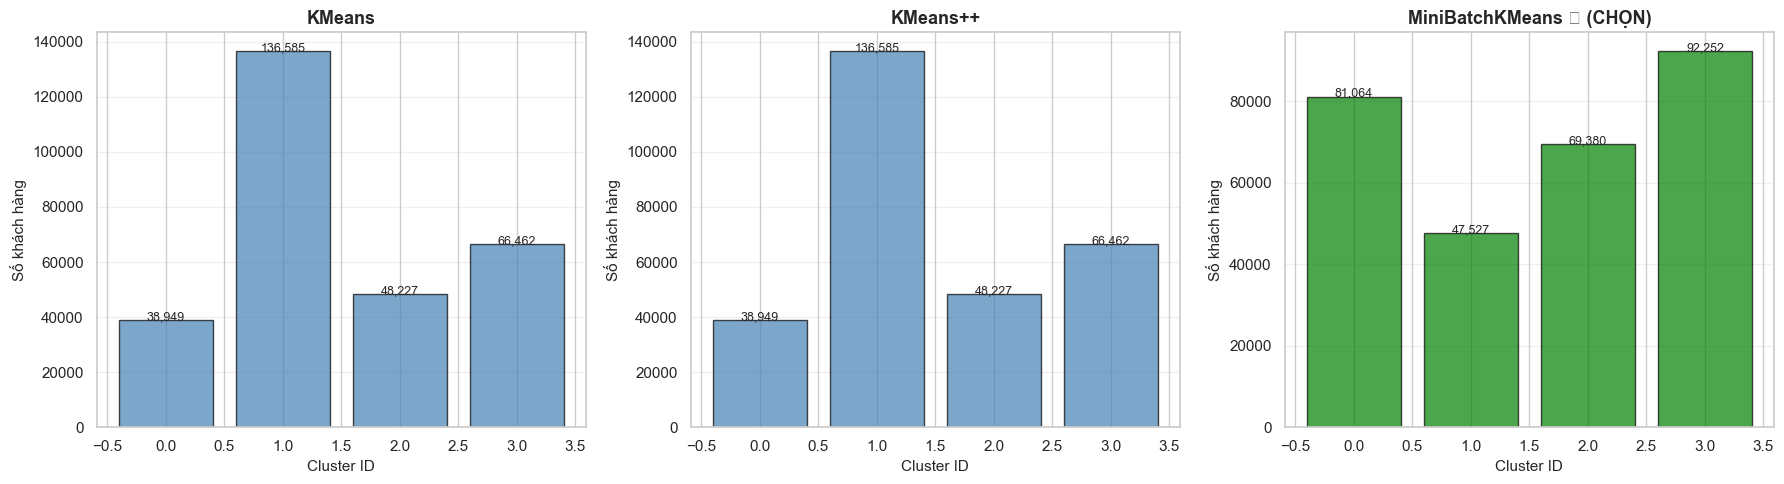


✅ Đã lưu biểu đồ vào: clustering_model_comparison_detailed.png

🔍 KIỂM TRA SỰ KHÁC BIỆT GIỮA CÁC MÔ HÌNH
KMeans vs KMeans++:        100.00% giống nhau
KMeans vs MiniBatchKMeans: 5.30% giống nhau
KMeans++ vs MiniBatchKMeans: 5.30% giống nhau

⚠️ Kết quả: 3 mô hình cho kết quả KHÁC BIỆT đáng kể (<80%)
   → Việc chọn đúng mô hình có ý nghĩa quan trọng
   → Mô hình 'MiniBatchKMeans' được chọn vì có Silhouette Score cao nhất


In [27]:
# So sánh chi tiết 3 mô hình clustering
print("="*80)
print("📊 SO SÁNH CHI TIẾT 3 MÔ HÌNH CLUSTERING")
print("="*80)

comparison_data = []

for model_name, labels in [
    ("KMeans", labels_kmeans),
    ("KMeans++", labels_kmeans_pp),
    ("MiniBatchKMeans", labels_mini)
]:
    # Tính các metrics (dùng lại scores đã tính ở cell 32)
    if 'scores' in globals() and model_name in scores:
        sil_score = scores[model_name]
    else:
        sil_score = silhouette_score(X_scaled, labels)

    # Đếm số lượng mỗi cluster
    unique, counts = np.unique(labels, return_counts=True)
    cluster_sizes = dict(zip(unique, counts))

    # Tính độ lệch chuẩn của kích thước cluster (đo tính cân bằng)
    size_std = np.std(counts)
    size_mean = np.mean(counts)
    balance_score = 1 - (size_std / size_mean)  # Càng gần 1 càng cân bằng

    comparison_data.append({
        'Model': model_name,
        'Silhouette Score': sil_score,
        'Số Clusters': len(unique),
        'Cluster nhỏ nhất': counts.min(),
        'Cluster lớn nhất': counts.max(),
        'Kích thước TB': int(size_mean),
        'Balance Score': balance_score,
        'Được chọn': '✓' if model_name == best_model_name else ''
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(4))

# Vẽ biểu đồ phân phối cluster của từng mô hình
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, labels) in enumerate([
    ("KMeans", labels_kmeans),
    ("KMeans++", labels_kmeans_pp),
    ("MiniBatchKMeans", labels_mini)
]):
    unique, counts = np.unique(labels, return_counts=True)
    colors = ['green' if model_name == best_model_name else 'steelblue' for _ in unique]

    axes[idx].bar(unique, counts, color=colors, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel('Cluster ID', fontsize=11)
    axes[idx].set_ylabel('Số khách hàng', fontsize=11)

    title = f"{model_name}"
    if model_name == best_model_name:
        title += " ✓ (CHỌN)"
    axes[idx].set_title(title, fontsize=13, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

    # Thêm giá trị trên cột
    for i, (c, cnt) in enumerate(zip(unique, counts)):
        axes[idx].text(i, cnt + 100, f'{cnt:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('clustering_model_comparison_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Đã lưu biểu đồ vào: clustering_model_comparison_detailed.png")

# Kiểm tra xem các mô hình có cho kết quả giống nhau không
print("\n" + "="*80)
print("🔍 KIỂM TRA SỰ KHÁC BIỆT GIỮA CÁC MÔ HÌNH")
print("="*80)

# So sánh KMeans vs KMeans++
agreement_kmeans_pp = (labels_kmeans == labels_kmeans_pp).mean()
print(f"KMeans vs KMeans++:        {agreement_kmeans_pp:.2%} giống nhau")

# So sánh KMeans vs MiniBatch
agreement_kmeans_mini = (labels_kmeans == labels_mini).mean()
print(f"KMeans vs MiniBatchKMeans: {agreement_kmeans_mini:.2%} giống nhau")

# So sánh KMeans++ vs MiniBatch
agreement_pp_mini = (labels_kmeans_pp == labels_mini).mean()
print(f"KMeans++ vs MiniBatchKMeans: {agreement_pp_mini:.2%} giống nhau")

if agreement_kmeans_pp > 0.95 and agreement_kmeans_mini > 0.95:
    print("\n✅ Kết quả: 3 mô hình cho kết quả RẤT GIỐNG NHAU (>95%)")
    print("   → Lựa chọn mô hình nào cũng không ảnh hưởng nhiều")
elif min(agreement_kmeans_pp, agreement_kmeans_mini, agreement_pp_mini) < 0.80:
    print("\n⚠️ Kết quả: 3 mô hình cho kết quả KHÁC BIỆT đáng kể (<80%)")
    print("   → Việc chọn đúng mô hình có ý nghĩa quan trọng")
    print(f"   → Mô hình '{best_model_name}' được chọn vì có Silhouette Score cao nhất")
else:
    print("\n📊 Kết quả: 3 mô hình cho kết quả tương đối giống nhau (80-95%)")
    print(f"   → Mô hình '{best_model_name}' được ưu tiên vì chất lượng tốt hơn")

print("="*80)

### 📌 Tóm tắt: Cluster Feature được sử dụng

**TRẢ LỜI CÂU HỎI: "Cluster được gán vào đang lấy của mô hình nào?"**

#### ✅ Câu trả lời ngắn gọn:
Cluster feature được lấy từ **mô hình có Silhouette Score cao nhất** trong 3 mô hình:
- KMeans (chuẩn)
- KMeans++ (cải tiến khởi tạo)
- MiniBatchKMeans (nhanh hơn)

#### 🔍 Quy trình chi tiết:

1. **Huấn luyện 3 mô hình** trên cùng dữ liệu X_scaled
2. **Tính Silhouette Score** cho mỗi mô hình (đo chất lượng phân cụm)
3. **Chọn mô hình tốt nhất** (score cao nhất)
4. **Gán cluster** từ mô hình đó vào:
   - `customer_behavior["cluster"]` ← Cột này được dùng làm feature
5. **Lưu mô hình** tốt nhất vào `kmeans_cluster_model.joblib`

#### 📊 Ảnh hưởng đến Classification:

Khi training các mô hình phân loại (Logistic Regression, Random Forest, XGBoost):
- **Mô hình WITH Cluster** sẽ sử dụng cột `cluster` này làm feature bổ sung
- Nếu cluster có chất lượng tốt (high Silhouette Score) → Có thể cải thiện dự báo
- Nếu cluster không tốt → Không giúp hoặc có thể làm giảm hiệu suất

#### 💡 Để xem mô hình nào được chọn:
- Chạy cell ở trên → Xem output "🏆 MÔ HÌNH CLUSTERING TỐT NHẤT"
- Hoặc load lại: `joblib.load("kmeans_cluster_model.joblib").__class__.__name__`

#### ⚙️ Nếu muốn chọn mô hình khác:
```python
# Thay vì tự động chọn, có thể chọn thủ công:
# customer_behavior["cluster"] = labels_kmeans       # Dùng KMeans
# customer_behavior["cluster"] = labels_kmeans_pp    # Dùng KMeans++
# customer_behavior["cluster"] = labels_mini         # Dùng MiniBatchKMeans
```

Nhưng **không khuyến khích** vì Silhouette Score là tiêu chí khách quan để đánh giá chất lượng.

### 4.6. Lưu mô hình clustering

In [28]:
# Lưu mô hình tốt nhất
joblib.dump(best_model, "kmeans_cluster_model.joblib")
print("✅ Đã lưu mô hình clustering vào kmeans_cluster_model.joblib")

# Lưu scaler
joblib.dump(scaler, "cluster_scaler.joblib")
print("✅ Đã lưu scaler vào cluster_scaler.joblib")

# Lưu danh sách features
import json
with open('cluster_features.json', 'w') as f:
    json.dump(cluster_features, f)
print("✅ Đã lưu danh sách features vào cluster_features.json")

✅ Đã lưu mô hình clustering vào kmeans_cluster_model.joblib
✅ Đã lưu scaler vào cluster_scaler.joblib
✅ Đã lưu danh sách features vào cluster_features.json


In [29]:
# Test load lại mô hình
loaded_model = joblib.load("kmeans_cluster_model.joblib")
customer_behavior["cluster_loaded"] = loaded_model.predict(X_scaled)

# Kiểm tra xem kết quả có giống nhau không
print(f"✅ Kiểm tra model load: {(customer_behavior['cluster'] == customer_behavior['cluster_loaded']).all()}")

✅ Kiểm tra model load: True


### 4.7. Phân tích profile từng cluster
Xem đặc điểm trung bình của khách hàng trong mỗi cluster

In [30]:
# Tính giá trị trung bình của các features theo cluster
cluster_profile = (
    customer_behavior
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

print("=== PROFILE TRUNG BÌNH CỦA TỪNG CLUSTER ===")
display(cluster_profile)

# Lưu profile ra Excel để dễ phân tích
cluster_profile.to_excel("cluster_profile.xlsx")
print("\n✅ Đã lưu cluster profile vào cluster_profile.xlsx")

=== PROFILE TRUNG BÌNH CỦA TỪNG CLUSTER ===


,tx_cnt,tx_amount,transfer_cnt,payment_cnt,activity_cnt,unique_activity_types,transfer_app_cnt,interest_rate_view_cnt,loan_cnt_total,total_loan_est,avg_ca_balance,avg_td_balance,ca_acct_cnt,td_acct_cnt
cluster,,,,,,,,,,,,,,
0,0.00,2.455699e+04,0.00,0.00,2.26,0.29,0.00,0.36,1.33,8.484743e+07,0.00,47125349.26,0.00,0.22
1,29.61,2.601156e+08,20.77,1.65,307.03,11.61,19.87,46.26,1.54,9.611353e+08,9831729.96,40761571.45,1.02,0.33
2,0.04,5.505913e+05,0.01,0.01,8.37,1.13,0.01,1.40,6.78,6.138678e+09,2616992.23,5061005.33,1.00,0.04
3,0.09,3.697566e+05,0.02,0.00,8.42,1.33,0.03,1.34,0.02,6.893958e+06,4130083.08,66686866.67,1.00,0.37



✅ Đã lưu cluster profile vào cluster_profile.xlsx


In [31]:
# Xem median (giá trị trung vị) của một số chỉ số quan trọng
print("=== MEDIAN CỦA MỘT SỐ CHỈ SỐ QUAN TRỌNG ===")
display(customer_behavior.groupby("cluster")[[
    "tx_cnt",
    "activity_cnt",
    "loan_cnt_total",
    "avg_td_balance"
]].median())

=== MEDIAN CỦA MỘT SỐ CHỈ SỐ QUAN TRỌNG ===


,tx_cnt,activity_cnt,loan_cnt_total,avg_td_balance
cluster,,,,
0,0.0,0.0,0.0,0.0
1,12.0,182.0,0.0,0.0
2,0.0,0.0,6.0,0.0
3,0.0,0.0,0.0,0.0


In [32]:
# Profile chi tiết hơn
profile_detailed = customer_behavior.groupby("cluster")[
    [
        "tx_cnt", "transfer_cnt", "transfer_app_cnt",
        "loan_cnt_total", "total_loan_est",
        "avg_ca_balance", "avg_td_balance",
        "activity_cnt"
    ]
].mean().round(2)

print("=== PROFILE CHI TIẾT ===")
print(profile_detailed)

=== PROFILE CHI TIẾT ===
         tx_cnt  transfer_cnt  transfer_app_cnt  loan_cnt_total  \
cluster                                                           
0          0.00          0.00              0.00            1.33   
1         29.61         20.77             19.87            1.54   
2          0.04          0.01              0.01            6.78   
3          0.09          0.02              0.03            0.02   

         total_loan_est  avg_ca_balance  avg_td_balance  activity_cnt  
cluster                                                                
0          8.484743e+07            0.00     47125349.26          2.26  
1          9.611353e+08      9831729.96     40761571.45        307.03  
2          6.138678e+09      2616992.23      5061005.33          8.37  
3          6.893958e+06      4130083.08     66686866.67          8.42  


---
## PHẦN 5: TRỰC QUAN HÓA CLUSTERING

### 5.1. PCA để giảm chiều dữ liệu
Sử dụng PCA để chiếu dữ liệu từ nhiều chiều xuống 2 chiều để dễ trực quan hóa

In [33]:
# Áp dụng PCA để giảm xuống 2 chiều
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("✅ Đã áp dụng PCA")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Tổng phương sai giải thích được: {pca.explained_variance_ratio_.sum():.2%}")

✅ Đã áp dụng PCA
Explained variance ratio: [0.4794489  0.17665189]
Tổng phương sai giải thích được: 65.61%


In [34]:
# Tạo DataFrame cho PCA
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "KMeans": customer_behavior["cluster"],
    "KMeans++": customer_behavior["cluster_kmeans_pp"],
    "MiniBatch": customer_behavior["cluster_mini_kmeans"]
})

print("✅ Đã tạo DataFrame PCA")
display(pca_df.head())

✅ Đã tạo DataFrame PCA


,PC1,PC2,KMeans,KMeans++,MiniBatch
0,4.495866,-0.279172,1,2,1
1,1.071282,-0.064640,3,1,3
2,7.032992,-0.465948,1,2,1
3,-1.715151,-1.220531,0,3,0
4,-1.156248,1.910368,2,1,2


### 5.2. Vẽ biểu đồ scatter plot cho các cluster

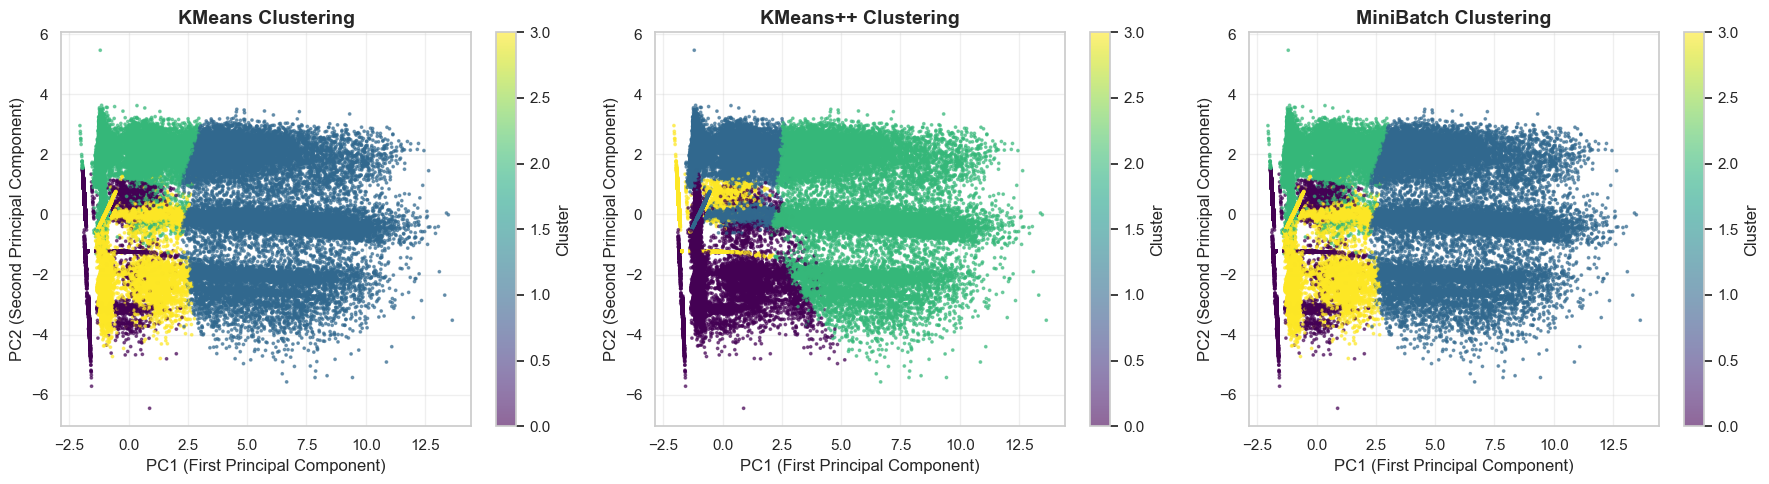

✅ Đã lưu biểu đồ vào clustering_comparison.png


In [35]:
# Vẽ biểu đồ so sánh 3 thuật toán clustering
models = ["KMeans", "KMeans++", "MiniBatch"]

plt.figure(figsize=(18, 5))

for i, model in enumerate(models, 1):
    plt.subplot(1, 3, i)
    scatter = plt.scatter(
        pca_df["PC1"],
        pca_df["PC2"],
        c=pca_df[model],
        s=3,
        alpha=0.6,
        cmap='viridis'
    )
    plt.title(f"{model} Clustering", fontsize=14, fontweight='bold')
    plt.xlabel("PC1 (First Principal Component)")
    plt.ylabel("PC2 (Second Principal Component)")
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Đã lưu biểu đồ vào clustering_comparison.png")

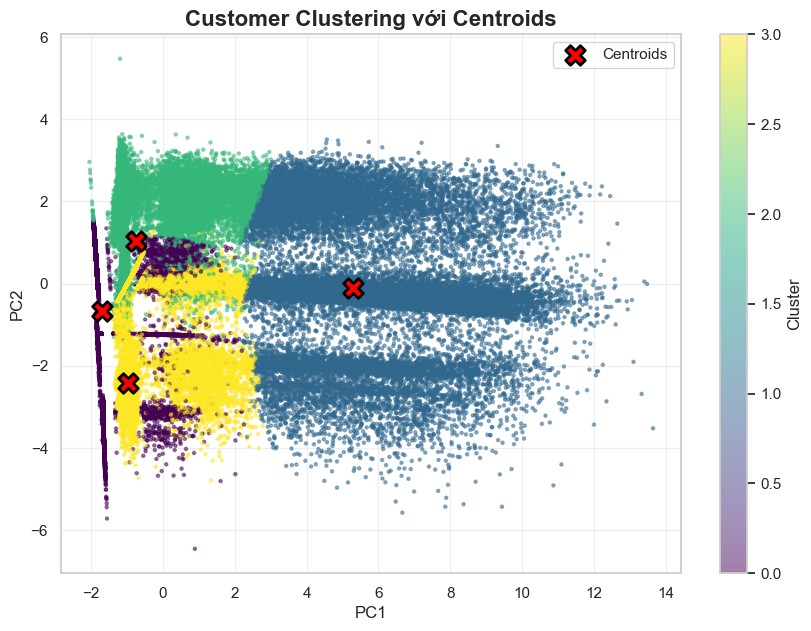

✅ Đã lưu biểu đồ vào clustering_with_centroids.png


In [36]:
# Vẽ biểu đồ với centroids
centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["KMeans"],
    s=5,
    alpha=0.5,
    cmap='viridis'
)
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c="red",
    s=200,
    marker="X",
    edgecolors='black',
    linewidths=2,
    label="Centroids"
)
plt.title("Customer Clustering với Centroids", fontsize=16, fontweight='bold')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('clustering_with_centroids.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Đã lưu biểu đồ vào clustering_with_centroids.png")

### 5.3. Xuất dữ liệu cluster ra Excel

In [37]:
# Xuất từng cluster ra sheet riêng trong Excel
with pd.ExcelWriter("clusters_data.xlsx") as writer:
    # Sheet tổng quan
    customer_behavior.to_excel(writer, sheet_name="All_Data", index=False)
    
    # Sheet từng cluster
    for c in sorted(customer_behavior["cluster"].unique()):
        df_cluster = customer_behavior[customer_behavior["cluster"] == c]
        df_cluster.to_excel(writer, sheet_name=f"Cluster_{c}", index=False)
    
    # Sheet profile
    cluster_profile.to_excel(writer, sheet_name="Profile")

print("✅ Đã xuất dữ liệu cluster ra clusters_data.xlsx")
print(f"   - Sheet 'All_Data': Tất cả khách hàng")
for c in sorted(customer_behavior["cluster"].unique()):
    count = (customer_behavior["cluster"] == c).sum()
    print(f"   - Sheet 'Cluster_{c}': {count:,} khách hàng")
print(f"   - Sheet 'Profile': Đặc điểm trung bình từng cluster")

✅ Đã xuất dữ liệu cluster ra clusters_data.xlsx
   - Sheet 'All_Data': Tất cả khách hàng
   - Sheet 'Cluster_0': 81,064 khách hàng
   - Sheet 'Cluster_1': 47,527 khách hàng
   - Sheet 'Cluster_2': 69,380 khách hàng
   - Sheet 'Cluster_3': 92,252 khách hàng
   - Sheet 'Profile': Đặc điểm trung bình từng cluster


---
## PHẦN 6: DỰ BÁO MỞ THẺ TÍN DỤNG (CLASSIFICATION)

### 6.1. Đọc dữ liệu thẻ tín dụng & tạo label
Mục tiêu: Dự đoán khách hàng có mở thẻ tín dụng hay không

In [38]:
# Đọc dữ liệu thẻ tín dụng
df_card = pd.read_excel("data/Data_Card.xlsx", sheet_name="in")
print(f"✅ Đã đọc dữ liệu thẻ: {df_card.shape}")
display(df_card.head())

✅ Đã đọc dữ liệu thẻ: (871589, 4)


,MONTH,COUNT_CREDITCARD,COUNT_DEBITCARD,CUSTOMER_NUMBER
0,2019-09-30,0,1,914326
1,2019-04-30,0,1,914326
2,2019-11-30,0,1,914326
3,2019-08-31,0,1,914326
4,2019-12-31,0,1,914326


In [39]:
# Tạo label: khách hàng đã từng có ít nhất 1 thẻ tín dụng?
card_label = (
    df_card.groupby("CUSTOMER_NUMBER")["COUNT_CREDITCARD"]
    .max()                  # Lấy số thẻ max trong lịch sử
    .gt(0)                  # Kiểm tra > 0
    .astype(int)            # Chuyển về 0/1
    .rename("has_creditcard")
    .reset_index()
)

print(f"✅ Đã tạo label cho {len(card_label):,} khách hàng")
display(card_label.head())
print(f"\nPhân phối label:")
print(card_label["has_creditcard"].value_counts())
print(f"\nTỷ lệ có thẻ: {card_label['has_creditcard'].mean():.2%}")

✅ Đã tạo label cho 150,459 khách hàng


,CUSTOMER_NUMBER,has_creditcard
0,0,0
1,3,0
2,8,1
3,9,0
4,13,0



Phân phối label:
has_creditcard
0    108085
1     42374
Name: count, dtype: int64

Tỷ lệ có thẻ: 28.16%


In [40]:
# Merge label vào bảng customer_behavior
df_cluster = customer_behavior.merge(card_label, on="CUSTOMER_NUMBER", how="left")
df_cluster["has_creditcard"] = df_cluster["has_creditcard"].fillna(0).astype(int)

print(f"✅ Đã merge label: {df_cluster.shape}")
print(f"\nPhân phối label sau merge:")
print(df_cluster["has_creditcard"].value_counts())

display(df_cluster[["CUSTOMER_NUMBER","cluster","has_creditcard"]].head())

✅ Đã merge label: (290223, 40)

Phân phối label sau merge:
has_creditcard
0    247849
1     42374
Name: count, dtype: int64


,CUSTOMER_NUMBER,cluster,has_creditcard
0,639362,1,0
1,452440,3,0
2,326290,1,0
3,20802,0,0
4,114244,2,0


### 6.2. Phân tích mối quan hệ giữa cluster và việc có thẻ tín dụng

In [41]:
# Tính tỷ lệ có thẻ theo từng cluster
cluster_card = (
    df_cluster.groupby("cluster")["has_creditcard"]
    .agg(n_customers="count", n_has_card="sum", rate="mean")
    .reset_index()
)
cluster_card["rate_%"] = (cluster_card["rate"] * 100).round(2)

print("=== TỶ LỆ CÓ THẺ TÍN DỤNG THEO CLUSTER ===")
display(cluster_card.sort_values("rate_%", ascending=False))

=== TỶ LỆ CÓ THẺ TÍN DỤNG THEO CLUSTER ===


,cluster,n_customers,n_has_card,rate,rate_%
0,0,81064,23893,0.294742,29.47
1,1,47527,7346,0.154565,15.46
2,2,69380,10211,0.147175,14.72
3,3,92252,924,0.010016,1.00


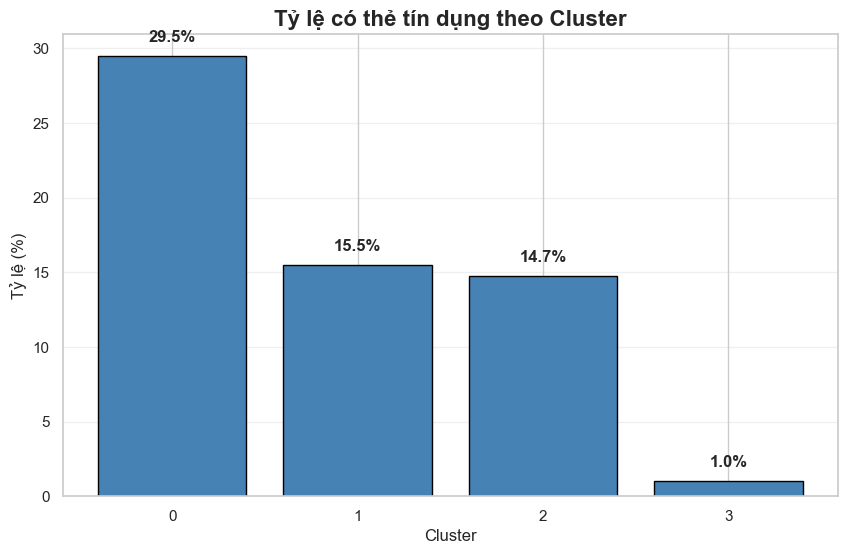

✅ Đã lưu biểu đồ vào creditcard_rate_by_cluster.png


In [42]:
# Vẽ biểu đồ tỷ lệ có thẻ theo cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_card["cluster"].astype(str), cluster_card["rate_%"], color='steelblue', edgecolor='black')
plt.title("Tỷ lệ có thẻ tín dụng theo Cluster", fontsize=16, fontweight='bold')
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Tỷ lệ (%)", fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Thêm giá trị trên mỗi cột
for i, v in enumerate(cluster_card["rate_%"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.savefig('creditcard_rate_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Đã lưu biểu đồ vào creditcard_rate_by_cluster.png")

In [43]:
# Kiểm định Chi-square để xem có mối quan hệ thống kê không
ct = pd.crosstab(df_cluster["cluster"], df_cluster["has_creditcard"])
chi2, p, dof, exp = chi2_contingency(ct)

print("=== KIỂM ĐỊNH CHI-SQUARE ===")
print("Contingency table:")
print(ct)
print(f"\nChi2 statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.6f}")

if p < 0.05:
    print("\n✅ Có mối quan hệ có ý nghĩa thống kê giữa cluster và việc có thẻ tín dụng")
else:
    print("\n⚠️ Không có mối quan hệ có ý nghĩa thống kê")

=== KIỂM ĐỊNH CHI-SQUARE ===
Contingency table:
has_creditcard      0      1
cluster                     
0               57171  23893
1               40181   7346
2               59169  10211
3               91328    924

Chi2 statistic: 28093.89
Degrees of freedom: 3
P-value: 0.000000

✅ Có mối quan hệ có ý nghĩa thống kê giữa cluster và việc có thẻ tín dụng


### 6.3. Chia train/test data

In [44]:
# Sử dụng các features giống phần clustering (không bao gồm cluster)
base_features = cluster_features[:]

# Tạo X (features) và y (label)
X_base = df_cluster[base_features].copy()
y = df_cluster["has_creditcard"].astype(int)

# Chia train/test với stratify để giữ tỷ lệ label
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, 
    test_size=0.2,      # 20% cho test
    random_state=42,    # Cố định seed để reproduce
    stratify=y          # Giữ tỷ lệ label trong train/test
)

print(f"✅ Đã chia dữ liệu:")
print(f"   - Train: {X_train.shape[0]:,} samples")
print(f"   - Test:  {X_test.shape[0]:,} samples")
print(f"\nPhân phối label trong train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nPhân phối label trong test:")
print(y_test.value_counts(normalize=True).round(3))

✅ Đã chia dữ liệu:
   - Train: 232,178 samples
   - Test:  58,045 samples

Phân phối label trong train:
has_creditcard
0    0.854
1    0.146
Name: proportion, dtype: float64

Phân phối label trong test:
has_creditcard
0    0.854
1    0.146
Name: proportion, dtype: float64


In [ ]:
# Tạo cluster feature KHÔNG bị rò rỉ dữ liệu (fit trên train, áp dụng cho test)
# Lưu ý: dùng cùng bộ features như clustering, nhưng fit chỉ trên train

# Fit scaler trên train
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

# Fit KMeans trên train
kmeans_clf = KMeans(n_clusters=4, random_state=42, n_init=100)
cluster_train = kmeans_clf.fit_predict(X_train_scaled)
cluster_test = kmeans_clf.predict(X_test_scaled)

# Gắn cluster vào train/test
X_train_with_cluster = X_train.copy()
X_test_with_cluster = X_test.copy()
X_train_with_cluster["cluster"] = cluster_train
X_test_with_cluster["cluster"] = cluster_test

print("✅ Đã tạo cluster cho classification (không rò rỉ)")
print(f"Train clusters: {pd.Series(cluster_train).value_counts().sort_index().to_dict()}")
print(f"Test clusters: {pd.Series(cluster_test).value_counts().sort_index().to_dict()}")

---
## PHẦN 7: MÔ HÌNH PHÂN LOẠI - BASELINE

### 7.1. Model A: Logistic Regression (không có cluster feature)

In [45]:
# Xây dựng pipeline cho Model A
model_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),      # Xử lý giá trị thiếu
    ("scaler", StandardScaler()),                       # Chuẩn hóa
    ("clf", LogisticRegression(                        # Logistic Regression
        max_iter=2000, 
        class_weight="balanced"  # Tự động cân bằng trọng số các class
    ))
])

# Huấn luyện
model_A.fit(X_train, y_train)
print("✅ Đã huấn luyện Model A")

# Dự đoán
proba_A = model_A.predict_proba(X_test)[:, 1]  # Xác suất class 1
pred_A = (proba_A >= 0.5).astype(int)          # Ngưỡng 0.5

# Đánh giá
print("\n" + "="*50)
print("MODEL A: Logistic Regression (no cluster)")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_test, proba_A):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, proba_A):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_A))
print(f"\nClassification Report:")
print(classification_report(y_test, pred_A, digits=4))

✅ Đã huấn luyện Model A

MODEL A: Logistic Regression (no cluster)
ROC-AUC: 0.8773
PR-AUC:  0.6259

Confusion Matrix:
[[33613 15957]
 [ 1368  7107]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9609    0.6781    0.7951     49570
           1     0.3081    0.8386    0.4507      8475

    accuracy                         0.7015     58045
   macro avg     0.6345    0.7583    0.6229     58045
weighted avg     0.8656    0.7015    0.7448     58045



### 7.2. Model B: Logistic Regression (có cluster feature)
Thêm cluster làm feature để xem có cải thiện hiệu suất không

In [ ]:
# Thêm cluster vào feature set (không rò rỉ)
X_plus = X_train_with_cluster.copy()
X2_train, X2_test = X_train_with_cluster, X_test_with_cluster

# Pipeline: xử lý numeric + one-hot encoding cluster
num_cols = base_features
cat_cols = ["cluster"]

preprocess_B = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model_B = Pipeline(steps=[
    ("preprocess", preprocess_B),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

# Huấn luyện
model_B.fit(X2_train, y_train)
print("✅ Đã huấn luyện Model B")

# Dự đoán
proba_B = model_B.predict_proba(X2_test)[:, 1]
pred_B = (proba_B >= 0.5).astype(int)

# Đánh giá
print("\n" + "="*50)
print("MODEL B: Logistic Regression (with cluster)")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_test, proba_B):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, proba_B):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_B))
print(f"\nClassification Report:")
print(classification_report(y_test, pred_B, digits=4))

✅ Đã huấn luyện Model B

MODEL B: Logistic Regression (with cluster)
ROC-AUC: 0.8799
PR-AUC:  0.6253

Confusion Matrix:
[[33470 16100]
 [ 1334  7141]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9617    0.6752    0.7934     49570
           1     0.3073    0.8426    0.4503      8475

    accuracy                         0.6996     58045
   macro avg     0.6345    0.7589    0.6218     58045
weighted avg     0.8661    0.6996    0.7433     58045



### 7.3. So sánh Model A vs Model B

In [47]:
# Tính các chỉ số
auc_A = roc_auc_score(y_test, proba_A)
auc_B = roc_auc_score(y2_test, proba_B)

prauc_A = average_precision_score(y_test, proba_A)
prauc_B = average_precision_score(y2_test, proba_B)

print("=== SO SÁNH MODEL A vs MODEL B ===")
print(f"\nROC-AUC:")
print(f"  Model A (no cluster):  {auc_A:.4f}")
print(f"  Model B (with cluster): {auc_B:.4f}")
print(f"  Chênh lệch: {auc_B - auc_A:+.4f}")

print(f"\nPR-AUC:")
print(f"  Model A:  {prauc_A:.4f}")
print(f"  Model B:  {prauc_B:.4f}")
print(f"  Chênh lệch: {prauc_B - prauc_A:+.4f}")

if auc_B > auc_A:
    print("\n✅ Model B tốt hơn → Cluster feature giúp tăng khả năng dự báo")
else:
    print("\n⚠️ Model B không tốt hơn → Cluster chủ yếu hữu ích cho phân tích, không tăng dự báo nhiều")

=== SO SÁNH MODEL A vs MODEL B ===

ROC-AUC:
  Model A (no cluster):  0.8773
  Model B (with cluster): 0.8799
  Chênh lệch: +0.0026

PR-AUC:
  Model A:  0.6259
  Model B:  0.6253
  Chênh lệch: -0.0005

✅ Model B tốt hơn → Cluster feature giúp tăng khả năng dự báo


### 7.4. Feature Importance
Xem feature nào quan trọng nhất trong việc dự báo

=== TOP 15 FEATURES QUAN TRỌNG NHẤT ===


,feature,importance,std
8,loan_cnt_total,0.241403,0.001922
12,ca_acct_cnt,0.172625,0.002150
5,unique_activity_types,0.039477,0.000928
2,transfer_cnt,0.021418,0.000314
0,tx_cnt,0.020357,0.001044
3,payment_cnt,0.009324,0.000279
6,transfer_app_cnt,0.008139,0.000631
9,total_loan_est,0.002071,0.000362
7,interest_rate_view_cnt,0.000494,0.000212
10,avg_ca_balance,0.000095,0.000192


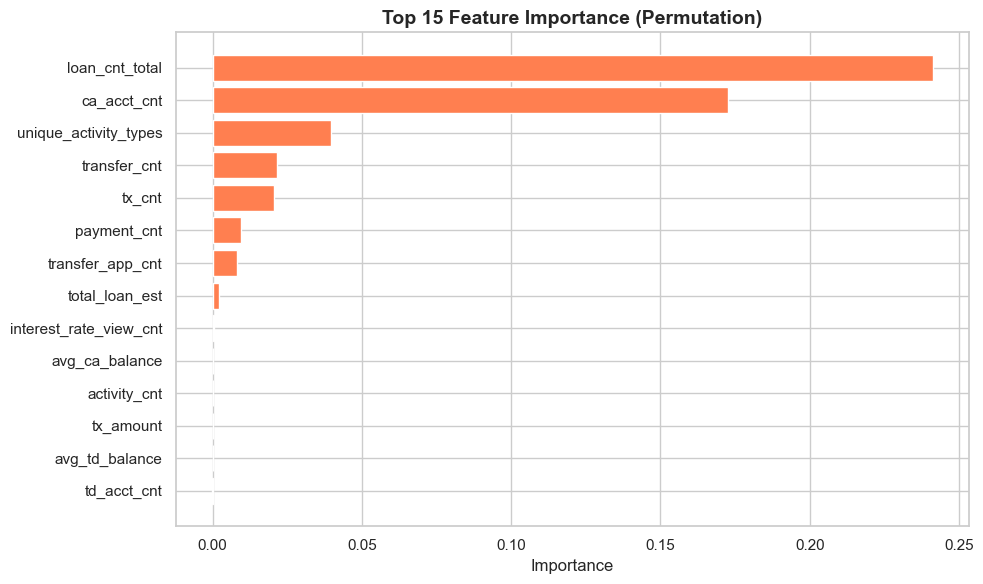

✅ Đã lưu biểu đồ vào feature_importance.png


In [48]:
# Sử dụng permutation importance trên Model A
r = permutation_importance(
    model_A, X_test, y_test, 
    n_repeats=10,           # Số lần lặp
    random_state=42, 
    scoring="roc_auc"
)

# Tạo DataFrame để dễ xem
imp = pd.DataFrame({
    "feature": base_features,
    "importance": r.importances_mean,
    "std": r.importances_std
}).sort_values("importance", ascending=False)

print("=== TOP 15 FEATURES QUAN TRỌNG NHẤT ===")
display(imp.head(15))

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(imp.head(15)["feature"][::-1], imp.head(15)["importance"][::-1], color='coral')
plt.xlabel("Importance", fontsize=12)
plt.title("Top 15 Feature Importance (Permutation)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Đã lưu biểu đồ vào feature_importance.png")

In [ ]:
# Kiểm tra độ quan trọng của feature bằng Permutation Importance trên mô hình tốt nhất
# Ưu tiên dùng XGBoost với cluster nếu đã train, nếu không thì dùng Logistic Regression (Model A)

if "model_xgb_B" in globals():
    model_for_imp = model_xgb_B
    X_imp = X2_test
    y_imp = y2_test
    model_name = "XGBoost (with cluster)"
elif "model_B" in globals():
    model_for_imp = model_B
    X_imp = X2_test
    y_imp = y2_test
    model_name = "Logistic Regression (with cluster)"
else:
    model_for_imp = model_A
    X_imp = X_test
    y_imp = y_test
    model_name = "Logistic Regression (no cluster)"

print(f"\n=== FEATURE IMPORTANCE ({model_name}) ===")

r2 = permutation_importance(
    model_for_imp,
    X_imp,
    y_imp,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

# Lấy đúng danh sách feature tương ứng
if "cluster" in X_imp.columns:
    imp_features = X_imp.columns.tolist()
else:
    imp_features = base_features

imp2 = pd.DataFrame({
    "feature": imp_features,
    "importance": r2.importances_mean,
    "std": r2.importances_std
}).sort_values("importance", ascending=False)

print("=== TOP 20 FEATURES QUAN TRỌNG NHẤT ===")
display(imp2.head(20))

# Vẽ biểu đồ
plt.figure(figsize=(10, 7))
plt.barh(imp2.head(20)["feature"][::-1], imp2.head(20)["importance"][::-1], color='teal')
plt.xlabel("Importance", fontsize=12)
plt.title(f"Top 20 Feature Importance ({model_name})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_top20.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Đã lưu biểu đồ vào feature_importance_top20.png")

In [ ]:
# Chuyển importance sang % để dễ loại bỏ feature ít ảnh hưởng
# Dùng kết quả imp2 của cell trước

tmp = imp2.copy()

# Lấy trị tuyệt đối và quy về %
tmp["abs_importance"] = tmp["importance"].abs()
abs_sum = tmp["abs_importance"].sum()

if abs_sum == 0:
    print("⚠️ Tổng importance = 0, không thể quy về %")
else:
    tmp["importance_pct"] = (tmp["abs_importance"] / abs_sum * 100).round(4)

    print("=== TOP 20 FEATURE IMPORTANCE (%) ===")
    display(tmp[["feature", "importance", "importance_pct"]].head(20))

    # Gợi ý loại bỏ các feature dưới ngưỡng %
    threshold_pct = 0.5  # có thể đổi thành 0.3 hoặc 1.0 tùy ý
    low_impact = tmp[tmp["importance_pct"] < threshold_pct]["feature"].tolist()

    print(f"\nGợi ý loại bỏ (importance < {threshold_pct}%): {len(low_impact)} features")
    print(low_impact)

    # Lưu danh sách ra file để tiện theo dõi
    pd.Series(low_impact, name="low_impact_features").to_csv("low_impact_features.csv", index=False)
    print("✅ Đã lưu danh sách low_impact_features.csv")

---
## PHẦN 8: MÔ HÌNH PHÂN LOẠI - NÂNG CAO

### 8.1. Random Forest (không có cluster)

In [49]:
# Xây dựng pipeline cho Random Forest
model_rf_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=100,           # 100 cây
        random_state=42, 
        class_weight="balanced",
        n_jobs=-1                   # Sử dụng tất cả CPU cores
    ))
])

# Huấn luyện
model_rf_A.fit(X_train, y_train)
print("✅ Đã huấn luyện Random Forest Model A")

# Dự đoán
proba_rf_A = model_rf_A.predict_proba(X_test)[:, 1]
pred_rf_A = (proba_rf_A >= 0.5).astype(int)

# Đánh giá
print("\n" + "="*50)
print("MODEL RF A: Random Forest (no cluster)")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_test, proba_rf_A):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, proba_rf_A):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_rf_A))
print(f"\nClassification Report:")
print(classification_report(y_test, pred_rf_A, digits=4))

✅ Đã huấn luyện Random Forest Model A

MODEL RF A: Random Forest (no cluster)
ROC-AUC: 0.9212
PR-AUC:  0.7974

Confusion Matrix:
[[48837   733]
 [ 2747  5728]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9467    0.9852    0.9656     49570
           1     0.8866    0.6759    0.7670      8475

    accuracy                         0.9400     58045
   macro avg     0.9166    0.8305    0.8663     58045
weighted avg     0.9380    0.9400    0.9366     58045



### 8.2. Random Forest (có cluster)

In [50]:
# Xây dựng pipeline cho Random Forest với cluster
model_rf_B = Pipeline(steps=[
    ("preprocess", preprocess_B),
    ("clf", RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Huấn luyện
model_rf_B.fit(X2_train, y2_train)
print("✅ Đã huấn luyện Random Forest Model B")

# Dự đoán
proba_rf_B = model_rf_B.predict_proba(X2_test)[:, 1]
pred_rf_B = (proba_rf_B >= 0.5).astype(int)

# Đánh giá
print("\n" + "="*50)
print("MODEL RF B: Random Forest (with cluster)")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_rf_B):.4f}")
print(f"PR-AUC:  {average_precision_score(y2_test, proba_rf_B):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y2_test, pred_rf_B))
print(f"\nClassification Report:")
print(classification_report(y2_test, pred_rf_B, digits=4))

✅ Đã huấn luyện Random Forest Model B

MODEL RF B: Random Forest (with cluster)
ROC-AUC: 0.9211
PR-AUC:  0.7959

Confusion Matrix:
[[48831   739]
 [ 2743  5732]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9468    0.9851    0.9656     49570
           1     0.8858    0.6763    0.7670      8475

    accuracy                         0.9400     58045
   macro avg     0.9163    0.8307    0.8663     58045
weighted avg     0.9379    0.9400    0.9366     58045



### 8.3. XGBoost (không có cluster)

In [51]:
# Xây dựng pipeline cho XGBoost
model_xgb_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators=100, 
        random_state=42, 
        scale_pos_weight=1,
        use_label_encoder=False, 
        eval_metric="logloss",
        tree_method='hist'          # Nhanh hơn
    ))
])

# Huấn luyện
model_xgb_A.fit(X_train, y_train)
print("✅ Đã huấn luyện XGBoost Model A")

# Dự đoán
proba_xgb_A = model_xgb_A.predict_proba(X_test)[:, 1]
pred_xgb_A = (proba_xgb_A >= 0.5).astype(int)

# Đánh giá
print("\n" + "="*50)
print("MODEL XGB A: XGBoost (no cluster)")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_test, proba_xgb_A):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, proba_xgb_A):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_xgb_A))
print(f"\nClassification Report:")
print(classification_report(y_test, pred_xgb_A, digits=4))

d:\DATN1\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:00:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Đã huấn luyện XGBoost Model A

MODEL XGB A: XGBoost (no cluster)
ROC-AUC: 0.9430
PR-AUC:  0.8454

Confusion Matrix:
[[49011   559]
 [ 2662  5813]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9485    0.9887    0.9682     49570
           1     0.9123    0.6859    0.7831      8475

    accuracy                         0.9445     58045
   macro avg     0.9304    0.8373    0.8756     58045
weighted avg     0.9432    0.9445    0.9412     58045



### 8.4. XGBoost (có cluster)

In [52]:
# Xây dựng pipeline cho XGBoost với cluster
model_xgb_B = Pipeline(steps=[
    ("preprocess", preprocess_B),
    ("clf", XGBClassifier(
        n_estimators=100, 
        random_state=42, 
        scale_pos_weight=1,
        use_label_encoder=False, 
        eval_metric="logloss",
        tree_method='hist'
    ))
])

# Huấn luyện
model_xgb_B.fit(X2_train, y2_train)
print("✅ Đã huấn luyện XGBoost Model B")

# Dự đoán
proba_xgb_B = model_xgb_B.predict_proba(X2_test)[:, 1]
pred_xgb_B = (proba_xgb_B >= 0.5).astype(int)

# Đánh giá
print("\n" + "="*50)
print("MODEL XGB B: XGBoost (with cluster)")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_xgb_B):.4f}")
print(f"PR-AUC:  {average_precision_score(y2_test, proba_xgb_B):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y2_test, pred_xgb_B))
print(f"\nClassification Report:")
print(classification_report(y2_test, pred_xgb_B, digits=4))

d:\DATN1\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:00:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Đã huấn luyện XGBoost Model B

MODEL XGB B: XGBoost (with cluster)
ROC-AUC: 0.9427
PR-AUC:  0.8446

Confusion Matrix:
[[48996   574]
 [ 2669  5806]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9483    0.9884    0.9680     49570
           1     0.9100    0.6851    0.7817      8475

    accuracy                         0.9441     58045
   macro avg     0.9292    0.8367    0.8748     58045
weighted avg     0.9427    0.9441    0.9408     58045



### 8.5. So sánh tất cả các mô hình

In [53]:
# Tổng hợp kết quả
results = pd.DataFrame([
    {"Model": "Logistic Regression", "With Cluster": "No", 
     "ROC-AUC": roc_auc_score(y_test, proba_A), 
     "PR-AUC": average_precision_score(y_test, proba_A)},
    {"Model": "Logistic Regression", "With Cluster": "Yes", 
     "ROC-AUC": roc_auc_score(y2_test, proba_B), 
     "PR-AUC": average_precision_score(y2_test, proba_B)},
    {"Model": "Random Forest", "With Cluster": "No", 
     "ROC-AUC": roc_auc_score(y_test, proba_rf_A), 
     "PR-AUC": average_precision_score(y_test, proba_rf_A)},
    {"Model": "Random Forest", "With Cluster": "Yes", 
     "ROC-AUC": roc_auc_score(y2_test, proba_rf_B), 
     "PR-AUC": average_precision_score(y2_test, proba_rf_B)},
    {"Model": "XGBoost", "With Cluster": "No", 
     "ROC-AUC": roc_auc_score(y_test, proba_xgb_A), 
     "PR-AUC": average_precision_score(y_test, proba_xgb_A)},
    {"Model": "XGBoost", "With Cluster": "Yes", 
     "ROC-AUC": roc_auc_score(y2_test, proba_xgb_B), 
     "PR-AUC": average_precision_score(y2_test, proba_xgb_B)},
])

print("=== SO SÁNH TẤT CẢ CÁC MÔ HÌNH ===")
display(results.sort_values("ROC-AUC", ascending=False))

# Lưu kết quả
results.to_excel("model_comparison.xlsx", index=False)
print("\n✅ Đã lưu kết quả vào model_comparison.xlsx")

=== SO SÁNH TẤT CẢ CÁC MÔ HÌNH ===


,Model,With Cluster,ROC-AUC,PR-AUC
4,XGBoost,No,0.942984,0.845420
5,XGBoost,Yes,0.942736,0.844566
2,Random Forest,No,0.921250,0.797401
3,Random Forest,Yes,0.921140,0.795889
1,Logistic Regression,Yes,0.879862,0.625335
0,Logistic Regression,No,0.877250,0.625870



✅ Đã lưu kết quả vào model_comparison.xlsx


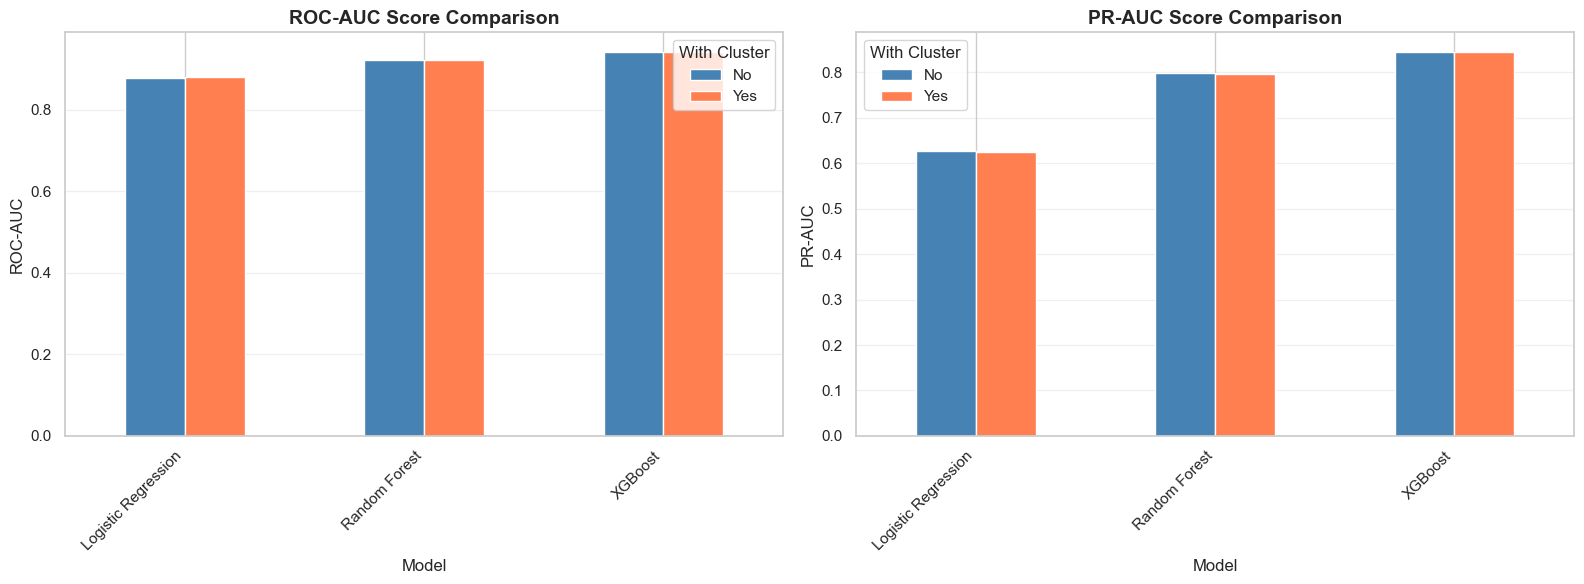

✅ Đã lưu biểu đồ vào model_comparison.png


In [54]:
# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC-AUC
results_pivot = results.pivot(index="Model", columns="With Cluster", values="ROC-AUC")
results_pivot.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('ROC-AUC Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('ROC-AUC', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].legend(title='With Cluster')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# PR-AUC
results_pivot = results.pivot(index="Model", columns="With Cluster", values="PR-AUC")
results_pivot.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('PR-AUC Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('PR-AUC', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].legend(title='With Cluster')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Đã lưu biểu đồ vào model_comparison.png")

---
## PHẦN 9: XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU

### 9.1. Kỹ thuật Oversampling
Kết hợp 3 kỹ thuật:
1. **RandomOverSampler**: Nhân bản mẫu thiểu số
2. **BorderlineSMOTE**: Sinh mẫu mới gần biên quyết định
3. **ADASYN**: Sinh mẫu mới cho vùng khó phân biệt

In [55]:
# Hàm kết hợp 3 kỹ thuật oversampling
def combine_oversampling(X, y):
    """Kết hợp 3 kỹ thuật oversampling để xử lý mất cân bằng dữ liệu"""
    # 1. Random OverSampler: tăng số lượng mẫu của lớp thiểu số
    ros = RandomOverSampler(random_state=42)
    X_ros, y_ros = ros.fit_resample(X, y)
    print(f"  After RandomOverSampler: {X_ros.shape[0]:,} samples")
    
    # 2. Borderline SMOTE: sinh thêm mẫu mới gần biên quyết định
    smote = BorderlineSMOTE(random_state=42)
    X_smote, y_smote = smote.fit_resample(X_ros, y_ros)
    print(f"  After BorderlineSMOTE: {X_smote.shape[0]:,} samples")
    
    # 3. ADASYN: sinh thêm mẫu mới cho vùng khó phân biệt
    adasyn = ADASYN(random_state=42)
    X_final, y_final = adasyn.fit_resample(X_smote, y_smote)
    print(f"  After ADASYN: {X_final.shape[0]:,} samples")
    
    return X_final, y_final

# Áp dụng cho tập train
print("=== ÁP DỤNG OVERSAMPLING CHO TẬP TRAIN ===")
print(f"Trước oversampling: {X_train.shape[0]:,} samples")
print(f"Phân phối: {y_train.value_counts().to_dict()}")

X_train_bal, y_train_bal = combine_oversampling(X_train, y_train)

print(f"\nSau oversampling: {X_train_bal.shape[0]:,} samples")
print(f"Phân phối: {y_train_bal.value_counts().to_dict()}")
print(f"Tỷ lệ cân bằng: {y_train_bal.value_counts(normalize=True).round(3).to_dict()}")

=== ÁP DỤNG OVERSAMPLING CHO TẬP TRAIN ===
Trước oversampling: 232,178 samples
Phân phối: {0: 198279, 1: 33899}
  After RandomOverSampler: 396,558 samples
  After BorderlineSMOTE: 396,558 samples
  After ADASYN: 396,558 samples

Sau oversampling: 396,558 samples
Phân phối: {0: 198279, 1: 198279}
Tỷ lệ cân bằng: {0: 0.5, 1: 0.5}


### 9.2. Huấn luyện lại các mô hình với dữ liệu đã cân bằng

In [56]:
# Tạo lại các mô hình mới (fresh models)
model_A_bal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model_rf_A_bal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1))
])

model_xgb_A_bal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=1, 
                          use_label_encoder=False, eval_metric="logloss", tree_method='hist'))
])

print("✅ Đã tạo các mô hình mới")

✅ Đã tạo các mô hình mới


In [57]:
# Huấn luyện với dữ liệu đã cân bằng
print("=== HUẤN LUYỆN VỚI DỮ LIỆU ĐÃ CÂN BẰNG ===")

model_A_bal.fit(X_train_bal, y_train_bal)
print("✅ Logistic Regression: Done")

model_rf_A_bal.fit(X_train_bal, y_train_bal)
print("✅ Random Forest: Done")

model_xgb_A_bal.fit(X_train_bal, y_train_bal)
print("✅ XGBoost: Done")

=== HUẤN LUYỆN VỚI DỮ LIỆU ĐÃ CÂN BẰNG ===
✅ Logistic Regression: Done
✅ Random Forest: Done


d:\DATN1\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:01:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost: Done


In [58]:
# Áp dụng Oversampling cho dữ liệu WITH CLUSTER
print("\n" + "="*70)
print("ÁP DỤNG OVERSAMPLING CHO DỮ LIỆU CÓ CLUSTER")
print("="*70)

print(f"Trước oversampling: {X2_train.shape[0]:,} samples")
print(f"Phân phối: {y2_train.value_counts().to_dict()}")

X2_train_bal, y2_train_bal = combine_oversampling(X2_train, y2_train)

print(f"\nSau oversampling: {X2_train_bal.shape[0]:,} samples")
print(f"Phân phối: {y2_train_bal.value_counts().to_dict()}")
print(f"Tỷ lệ cân bằng: {y2_train_bal.value_counts(normalize=True).round(3).to_dict()}")



ÁP DỤNG OVERSAMPLING CHO DỮ LIỆU CÓ CLUSTER
Trước oversampling: 232,178 samples
Phân phối: {0: 198279, 1: 33899}
  After RandomOverSampler: 396,558 samples
  After BorderlineSMOTE: 396,558 samples
  After ADASYN: 396,558 samples

Sau oversampling: 396,558 samples
Phân phối: {0: 198279, 1: 198279}
Tỷ lệ cân bằng: {0: 0.5, 1: 0.5}


In [59]:
# Tạo các mô hình balanced WITH CLUSTER
print("\n=== TẠO CÁC MÔ HÌNH BALANCED VỚI CLUSTER ===")

model_B_bal = Pipeline(steps=[
    ("preprocess", preprocess_B),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model_rf_B_bal = Pipeline(steps=[
    ("preprocess", preprocess_B),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced", n_jobs=-1))
])

model_xgb_B_bal = Pipeline(steps=[
    ("preprocess", preprocess_B),
    ("clf", XGBClassifier(n_estimators=100, random_state=42, scale_pos_weight=1, 
                          use_label_encoder=False, eval_metric="logloss", tree_method='hist'))
])

print("✅ Đã tạo các mô hình balanced với cluster")



=== TẠO CÁC MÔ HÌNH BALANCED VỚI CLUSTER ===
✅ Đã tạo các mô hình balanced với cluster


In [60]:
# Huấn luyện các mô hình balanced WITH CLUSTER
print("\n=== HUẤN LUYỆN CÁC MÔ HÌNH BALANCED VỚI CLUSTER ===")

model_B_bal.fit(X2_train_bal, y2_train_bal)
print("✅ Logistic Regression (with cluster): Done")

model_rf_B_bal.fit(X2_train_bal, y2_train_bal)
print("✅ Random Forest (with cluster): Done")

model_xgb_B_bal.fit(X2_train_bal, y2_train_bal)
print("✅ XGBoost (with cluster): Done")



=== HUẤN LUYỆN CÁC MÔ HÌNH BALANCED VỚI CLUSTER ===
✅ Logistic Regression (with cluster): Done
✅ Random Forest (with cluster): Done


d:\DATN1\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:01:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost (with cluster): Done


In [61]:
# Đánh giá các mô hình balanced WITH CLUSTER
print("\n" + "="*50)
print("ĐÁNH GIÁ CÁC MÔ HÌNH BALANCED VỚI CLUSTER")
print("="*50)

# Logistic Regression (balanced + cluster)
proba_B_bal = model_B_bal.predict_proba(X2_test)[:, 1]
pred_B_bal = (proba_B_bal >= 0.5).astype(int)

print("\nMODEL B (Balanced + Cluster): Logistic Regression")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_B_bal):.4f}")
print(f"PR-AUC:  {average_precision_score(y2_test, proba_B_bal):.4f}")

# Random Forest (balanced + cluster)
proba_rf_B_bal = model_rf_B_bal.predict_proba(X2_test)[:, 1]
pred_rf_B_bal = (proba_rf_B_bal >= 0.5).astype(int)

print("\nMODEL RF B (Balanced + Cluster): Random Forest")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_rf_B_bal):.4f}")
print(f"PR-AUC:  {average_precision_score(y2_test, proba_rf_B_bal):.4f}")

# XGBoost (balanced + cluster)
proba_xgb_B_bal = model_xgb_B_bal.predict_proba(X2_test)[:, 1]
pred_xgb_B_bal = (proba_xgb_B_bal >= 0.5).astype(int)

print("\nMODEL XGB B (Balanced + Cluster): XGBoost")
print(f"ROC-AUC: {roc_auc_score(y2_test, proba_xgb_B_bal):.4f}")
print(f"PR-AUC:  {average_precision_score(y2_test, proba_xgb_B_bal):.4f}")



ĐÁNH GIÁ CÁC MÔ HÌNH BALANCED VỚI CLUSTER

MODEL B (Balanced + Cluster): Logistic Regression
ROC-AUC: 0.8796
PR-AUC:  0.6255

MODEL RF B (Balanced + Cluster): Random Forest
ROC-AUC: 0.9252
PR-AUC:  0.7981

MODEL XGB B (Balanced + Cluster): XGBoost
ROC-AUC: 0.9416
PR-AUC:  0.8424


In [62]:
# Tạo hàm tính toán tất cả các chỉ số đánh giá
from sklearn.metrics import precision_score, recall_score, f1_score

def calculate_all_metrics(y_true, y_pred, y_proba):
    """Tính tất cả các chỉ số đánh giá"""
    from sklearn.metrics import confusion_matrix
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    }

print("✅ Đã tạo hàm tính toán tất cả các chỉ số")


✅ Đã tạo hàm tính toán tất cả các chỉ số


### 9.3. Đánh giá các mô hình sau khi xử lý mất cân bằng

In [63]:
# Logistic Regression (balanced)
proba_A_bal = model_A_bal.predict_proba(X_test)[:, 1]
pred_A_bal = (proba_A_bal >= 0.5).astype(int)

print("\n" + "="*50)
print("MODEL A (Balanced): Logistic Regression")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_test, proba_A_bal):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, proba_A_bal):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_A_bal))
print(f"\nClassification Report:")
print(classification_report(y_test, pred_A_bal, digits=4))


MODEL A (Balanced): Logistic Regression
ROC-AUC: 0.8771
PR-AUC:  0.6266

Confusion Matrix:
[[33625 15945]
 [ 1372  7103]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9608    0.6783    0.7952     49570
           1     0.3082    0.8381    0.4507      8475

    accuracy                         0.7017     58045
   macro avg     0.6345    0.7582    0.6229     58045
weighted avg     0.8655    0.7017    0.7449     58045



In [64]:
# Random Forest (balanced)
proba_rf_A_bal = model_rf_A_bal.predict_proba(X_test)[:, 1]
pred_rf_A_bal = (proba_rf_A_bal >= 0.5).astype(int)

print("\n" + "="*50)
print("MODEL RF A (Balanced): Random Forest")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_test, proba_rf_A_bal):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, proba_rf_A_bal):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_rf_A_bal))
print(f"\nClassification Report:")
print(classification_report(y_test, pred_rf_A_bal, digits=4))


MODEL RF A (Balanced): Random Forest
ROC-AUC: 0.9256
PR-AUC:  0.8030

Confusion Matrix:
[[48139  1431]
 [ 2482  5993]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9510    0.9711    0.9609     49570
           1     0.8072    0.7071    0.7539      8475

    accuracy                         0.9326     58045
   macro avg     0.8791    0.8391    0.8574     58045
weighted avg     0.9300    0.9326    0.9307     58045



In [65]:
# XGBoost (balanced)
proba_xgb_A_bal = model_xgb_A_bal.predict_proba(X_test)[:, 1]
pred_xgb_A_bal = (proba_xgb_A_bal >= 0.5).astype(int)

print("\n" + "="*50)
print("MODEL XGB A (Balanced): XGBoost")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_test, proba_xgb_A_bal):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, proba_xgb_A_bal):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_xgb_A_bal))
print(f"\nClassification Report:")
print(classification_report(y_test, pred_xgb_A_bal, digits=4))


MODEL XGB A (Balanced): XGBoost
ROC-AUC: 0.9418
PR-AUC:  0.8427

Confusion Matrix:
[[46524  3046]
 [ 1818  6657]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9624    0.9386    0.9503     49570
           1     0.6861    0.7855    0.7324      8475

    accuracy                         0.9162     58045
   macro avg     0.8242    0.8620    0.8414     58045
weighted avg     0.9220    0.9162    0.9185     58045



### 9.4. So sánh trước và sau khi xử lý mất cân bằng

In [66]:
# Tính toán tất cả các chỉ số cho TẤT CẢ các mô hình
print("=== TÍNH TOÁN TẤT CẢ CÁC CHỈ SỐ ===\n")

comparison_data = []

# WITHOUT CLUSTER - Original
print("Logistic Regression (No Cluster, Original)...")
metrics = calculate_all_metrics(y_test, pred_A, proba_A)
comparison_data.append({**{"Model": "Logistic Regression", "Cluster": "No", "Data": "Original"}, **metrics})

print("Logistic Regression (No Cluster, Balanced)...")
metrics = calculate_all_metrics(y_test, pred_A_bal, proba_A_bal)
comparison_data.append({**{"Model": "Logistic Regression", "Cluster": "No", "Data": "Balanced"}, **metrics})

print("Random Forest (No Cluster, Original)...")
metrics = calculate_all_metrics(y_test, pred_rf_A, proba_rf_A)
comparison_data.append({**{"Model": "Random Forest", "Cluster": "No", "Data": "Original"}, **metrics})

print("Random Forest (No Cluster, Balanced)...")
metrics = calculate_all_metrics(y_test, pred_rf_A_bal, proba_rf_A_bal)
comparison_data.append({**{"Model": "Random Forest", "Cluster": "No", "Data": "Balanced"}, **metrics})

print("XGBoost (No Cluster, Original)...")
metrics = calculate_all_metrics(y_test, pred_xgb_A, proba_xgb_A)
comparison_data.append({**{"Model": "XGBoost", "Cluster": "No", "Data": "Original"}, **metrics})

print("XGBoost (No Cluster, Balanced)...")
metrics = calculate_all_metrics(y_test, pred_xgb_A_bal, proba_xgb_A_bal)
comparison_data.append({**{"Model": "XGBoost", "Cluster": "No", "Data": "Balanced"}, **metrics})

# WITH CLUSTER - Balanced
print("Logistic Regression (With Cluster, Balanced)...")
metrics = calculate_all_metrics(y2_test, pred_B_bal, proba_B_bal)
comparison_data.append({**{"Model": "Logistic Regression", "Cluster": "Yes", "Data": "Balanced"}, **metrics})

print("Random Forest (With Cluster, Balanced)...")
metrics = calculate_all_metrics(y2_test, pred_rf_B_bal, proba_rf_B_bal)
comparison_data.append({**{"Model": "Random Forest", "Cluster": "Yes", "Data": "Balanced"}, **metrics})

print("XGBoost (With Cluster, Balanced)...")
metrics = calculate_all_metrics(y2_test, pred_xgb_B_bal, proba_xgb_B_bal)
comparison_data.append({**{"Model": "XGBoost", "Cluster": "Yes", "Data": "Balanced"}, **metrics})

comparison = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("=== SO SÁNH ĐẦY ĐỦ TẤT CẢ CÁC MÔ HÌNH ===")
print("(Bao gồm 7 chỉ số: Accuracy, Precision, Recall, Specificity, F1, ROC-AUC, PR-AUC)")
print("="*80)
print("\nXếp hạng theo ROC-AUC:")
display(comparison.sort_values("ROC-AUC", ascending=False)[['Model', 'Cluster', 'Data', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']].round(4))

# Lưu kết quả
comparison.to_excel("balanced_comparison_complete.xlsx", index=False)
print("\n✅ Đã lưu kết quả chi tiết vào: balanced_comparison_complete.xlsx")

=== TÍNH TOÁN TẤT CẢ CÁC CHỈ SỐ ===

Logistic Regression (No Cluster, Original)...
Logistic Regression (No Cluster, Balanced)...
Random Forest (No Cluster, Original)...
Random Forest (No Cluster, Balanced)...
XGBoost (No Cluster, Original)...
XGBoost (No Cluster, Balanced)...
Logistic Regression (With Cluster, Balanced)...
Random Forest (With Cluster, Balanced)...
XGBoost (With Cluster, Balanced)...

=== SO SÁNH ĐẦY ĐỦ TẤT CẢ CÁC MÔ HÌNH ===
(Bao gồm 7 chỉ số: Accuracy, Precision, Recall, Specificity, F1, ROC-AUC, PR-AUC)

Xếp hạng theo ROC-AUC:


,Model,Cluster,Data,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
4,XGBoost,No,Original,0.9445,0.9123,0.6859,0.7831,0.9430,0.8454
5,XGBoost,No,Balanced,0.9162,0.6861,0.7855,0.7324,0.9418,0.8427
8,XGBoost,Yes,Balanced,0.9166,0.6879,0.7848,0.7332,0.9416,0.8424
3,Random Forest,No,Balanced,0.9326,0.8072,0.7071,0.7539,0.9256,0.8030
7,Random Forest,Yes,Balanced,0.9324,0.8066,0.7061,0.7530,0.9252,0.7981
2,Random Forest,No,Original,0.9400,0.8866,0.6759,0.7670,0.9212,0.7974
6,Logistic Regression,Yes,Balanced,0.6996,0.3071,0.8420,0.4501,0.8796,0.6255
0,Logistic Regression,No,Original,0.7015,0.3081,0.8386,0.4507,0.8773,0.6259
1,Logistic Regression,No,Balanced,0.7017,0.3082,0.8381,0.4507,0.8771,0.6266



✅ Đã lưu kết quả chi tiết vào: balanced_comparison_complete.xlsx


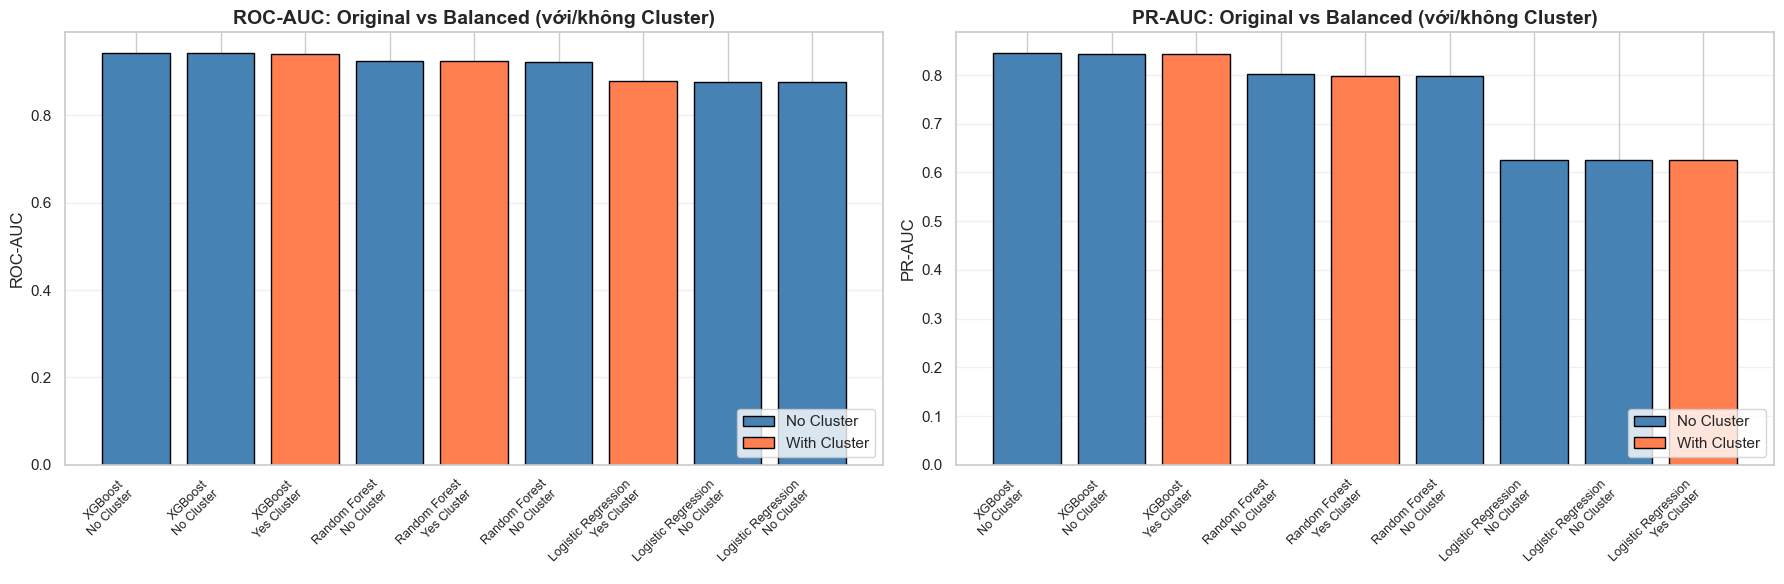

✅ Đã lưu biểu đồ vào balanced_comparison.png


In [67]:
# Vẽ biểu đồ so sánh (cập nhật cho cả Cluster feature)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Tạo nhãn combo cho biểu đồ
comparison['Label'] = comparison['Model'] + '\n' + comparison['Cluster'] + ' Cluster'

# ROC-AUC
comparison_sorted = comparison.sort_values('ROC-AUC', ascending=False)
colors = ['steelblue' if c == 'No' else 'coral' for c in comparison_sorted['Cluster']]
axes[0].bar(range(len(comparison_sorted)), comparison_sorted['ROC-AUC'], color=colors, edgecolor='black')
axes[0].set_xticks(range(len(comparison_sorted)))
axes[0].set_xticklabels(comparison_sorted['Label'], rotation=45, ha='right', fontsize=9)
axes[0].set_title('ROC-AUC: Original vs Balanced (với/không Cluster)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('ROC-AUC', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Thêm legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', edgecolor='black', label='No Cluster'),
                  Patch(facecolor='coral', edgecolor='black', label='With Cluster')]
axes[0].legend(handles=legend_elements, loc='lower right')

# PR-AUC
comparison_sorted = comparison.sort_values('PR-AUC', ascending=False)
colors = ['steelblue' if c == 'No' else 'coral' for c in comparison_sorted['Cluster']]
axes[1].bar(range(len(comparison_sorted)), comparison_sorted['PR-AUC'], color=colors, edgecolor='black')
axes[1].set_xticks(range(len(comparison_sorted)))
axes[1].set_xticklabels(comparison_sorted['Label'], rotation=45, ha='right', fontsize=9)
axes[1].set_title('PR-AUC: Original vs Balanced (với/không Cluster)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('PR-AUC', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('balanced_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Đã lưu biểu đồ vào balanced_comparison.png")

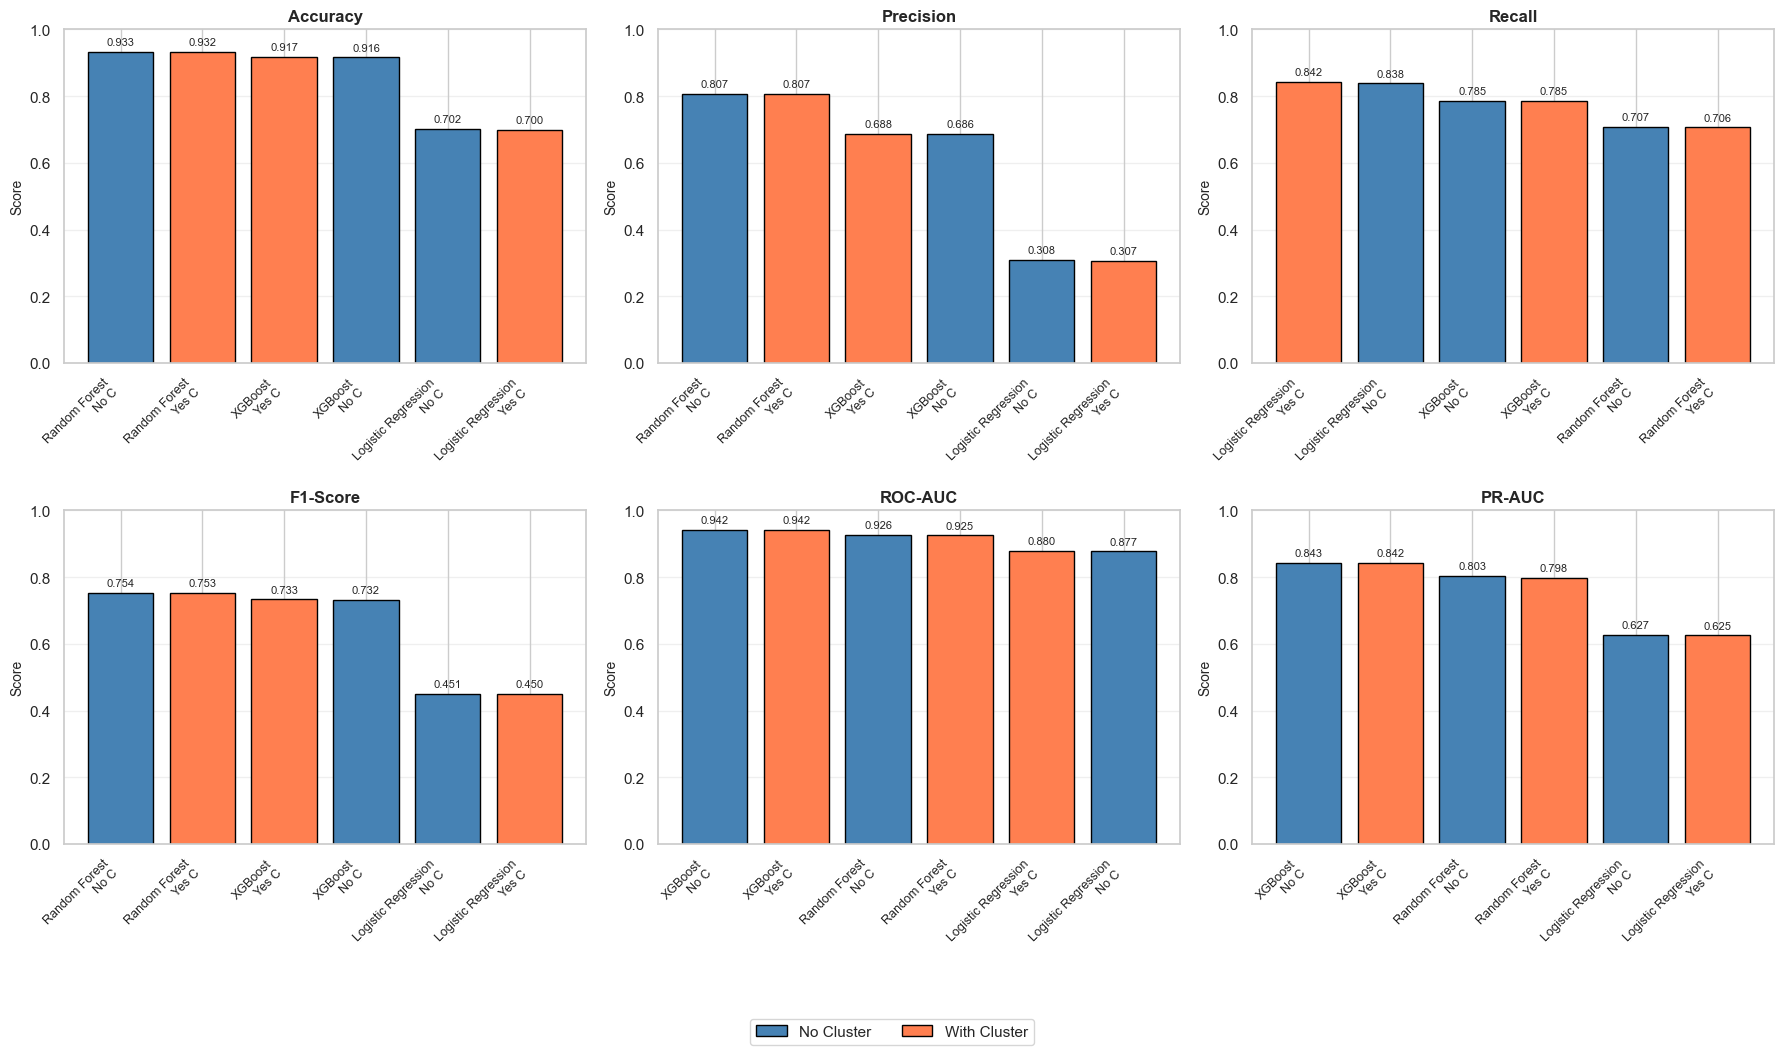

✅ Đã lưu biểu đồ chi tiết vào: metrics_comparison_detailed.png


In [68]:
# Biểu đồ so sánh TẤT CẢ các chỉ số
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Lọc chỉ lấy mô hình Balanced (cả No Cluster và With Cluster)
comparison_balanced = comparison[comparison['Data'] == 'Balanced'].copy()
comparison_balanced['Label'] = comparison_balanced['Model'] + '\n' + comparison_balanced['Cluster'] + ' C'

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    sorted_data = comparison_balanced.sort_values(metric, ascending=False)
    colors = ['steelblue' if c == 'No' else 'coral' for c in sorted_data['Cluster']]
    
    ax.bar(range(len(sorted_data)), sorted_data[metric], color=colors, edgecolor='black')
    ax.set_xticks(range(len(sorted_data)))
    ax.set_xticklabels(sorted_data['Label'], rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1])
    
    # Thêm giá trị trên cột
    for i, v in enumerate(sorted_data[metric]):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=8)

# Thêm legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', edgecolor='black', label='No Cluster'),
                  Patch(facecolor='coral', edgecolor='black', label='With Cluster')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig('metrics_comparison_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Đã lưu biểu đồ chi tiết vào: metrics_comparison_detailed.png")


## 📊 Giải thích 7 chỉ số đánh giá

| Chỉ số | Định nghĩa | Khi nào dùng | Công thức |
|--------|-----------|-----------|---------|
| **Accuracy** | % dự đoán đúng tổng thể | Dữ liệu cân bằng | (TP+TN)/(TP+TN+FP+FN) |
| **Precision** | Trong số khách hàng ta dự đoán "có thẻ", bao nhiêu % đúng? | Chi phí FP cao (phí quảng cáo sai) | TP/(TP+FP) |
| **Recall (Sensitivity)** | Trong số khách hàng thực sự "có thẻ", ta phát hiện được bao nhiêu %? | Chi phí FN cao (mất khách hàng tiềm năng) | TP/(TP+FN) |
| **Specificity** | Khả năng nhận diện đúng "không có thẻ" | Bài toán với class âm dương rõ | TN/(TN+FP) |
| **F1-Score** | Cân bằng Precision & Recall (trung bình điều hòa) | Dữ liệu mất cân bằng, cần balance | 2×(P×R)/(P+R) |
| **ROC-AUC** | Diện tích dưới đường cong ROC, đo khả năng phân biệt class | Dữ liệu cân bằng, so sánh mô hình | Từ 0→1 |
| **PR-AUC** | Diện tích dưới đường cong Precision-Recall | **Dữ liệu mất cân bằng** (tương tự bài này) | Từ 0→1 |

### 🎯 Lý do chọn 7 chỉ số này:

1. **Accuracy** = Tầm nhìn tổng quát nhất
2. **Precision + Recall** = Tìm hiểu trade-off  
3. **F1-Score** = Cân bằng chủ yếu
4. **Specificity** = Xem False Positive rate
5. **ROC-AUC** = Chỉ số chuẩn trong industy
6. **PR-AUC** = Tốt nhất cho dữ liệu mất cân bằng (như bài bạn)

### ⚠️ Case của bạn: Dữ liệu mất cân bằng
- Class "có thẻ" chỉ ~30-40%
- **Nên ưu tiên: F1-Score & PR-AUC** (không tin Accuracy quá!)
- Precision quan trọng: Không muốn gửi offer sai người
- Recall quan trọng: Không muốn mất khách hàng tiềm năng

In [69]:
# So sánh mô hình tốt nhất theo từng chỉ số
print("\n" + "="*80)
print("🏆 MÔ HÌNH TỐT NHẤT THEO TỪNG CHỈ SỐ")
print("="*80)

for metric in metrics_to_plot:
    best_idx = comparison[comparison['Data'] == 'Balanced'][metric].idxmax()
    best = comparison.loc[best_idx]
    print(f"\n{metric:15s}: {best['Model']:20s} (Cluster: {best['Cluster']}) = {best[metric]:.4f}")

# Xếp hạng TỔNG THỂ dựa trên các metric quan trọng
print("\n" + "="*80)
print("📊 XẾPS HẠNG TỔNG THỂ (Balanced models only)")
print("="*80)

comparison_bal = comparison[comparison['Data'] == 'Balanced'].copy()

# Tạo ranking score: ưu tiên F1-Score & PR-AUC
comparison_bal['Overall_Score'] = (
    comparison_bal['F1-Score'] * 0.3 +        # 30% F1-Score
    comparison_bal['PR-AUC'] * 0.3 +          # 30% PR-AUC
    comparison_bal['ROC-AUC'] * 0.2 +         # 20% ROC-AUC
    comparison_bal['Recall'] * 0.1 +          # 10% Recall
    comparison_bal['Precision'] * 0.1         # 10% Precision
)

ranking = comparison_bal.sort_values('Overall_Score', ascending=False)[
    ['Model', 'Cluster', 'Data', 'F1-Score', 'PR-AUC', 'ROC-AUC', 'Recall', 'Precision', 'Overall_Score']
].reset_index(drop=True)

ranking.index = ranking.index + 1
ranking.index.name = 'Rank'

print("\n(Trọng số: F1 30% + PR-AUC 30% + ROC-AUC 20% + Recall 10% + Precision 10%)\n")
display(ranking.round(4))

print("\n✅ Mô hình gợi ý sử dụng:")
best_overall = ranking.iloc[0]
print(f"   {best_overall['Model']} (Cluster: {best_overall['Cluster']})")
print(f"   Overall Score: {best_overall['Overall_Score']:.4f}")



🏆 MÔ HÌNH TỐT NHẤT THEO TỪNG CHỈ SỐ

Accuracy       : Random Forest        (Cluster: No) = 0.9326

Precision      : Random Forest        (Cluster: No) = 0.8072

Recall         : Logistic Regression  (Cluster: Yes) = 0.8420

F1-Score       : Random Forest        (Cluster: No) = 0.7539

ROC-AUC        : XGBoost              (Cluster: No) = 0.9418

PR-AUC         : XGBoost              (Cluster: No) = 0.8427

📊 XẾPS HẠNG TỔNG THỂ (Balanced models only)

(Trọng số: F1 30% + PR-AUC 30% + ROC-AUC 20% + Recall 10% + Precision 10%)



,Model,Cluster,Data,F1-Score,PR-AUC,ROC-AUC,Recall,Precision,Overall_Score
Rank,,,,,,,,,
1,XGBoost,Yes,Balanced,0.7332,0.8424,0.9416,0.7848,0.6879,0.8083
2,XGBoost,No,Balanced,0.7324,0.8427,0.9418,0.7855,0.6861,0.8080
3,Random Forest,No,Balanced,0.7539,0.8030,0.9256,0.7071,0.8072,0.8036
4,Random Forest,Yes,Balanced,0.7530,0.7981,0.9252,0.7061,0.8066,0.8016
5,Logistic Regression,Yes,Balanced,0.4501,0.6255,0.8796,0.8420,0.3071,0.6135
6,Logistic Regression,No,Balanced,0.4507,0.6266,0.8771,0.8381,0.3082,0.6132



✅ Mô hình gợi ý sử dụng:
   XGBoost (Cluster: Yes)
   Overall Score: 0.8083


### ⚠️ Về Trọng số Overall Score - Quan trọng!

**Câu hỏi: Trọng số (F1 30% + PR-AUC 30% + ROC-AUC 20% + Recall 10% + Precision 10%) dựa vào đâu?**

#### 🔴 Thực tế:
Trọng số này **KHÔNG có nguồn gốc khoa học cố định** - đây là một **heuristic** (phương pháp thực nghiệm) dựa trên:

1. **Kinh nghiệm thực tế** với dữ liệu mất cân bằng
2. **Đặc điểm bài toán**: 
   - Dữ liệu mất cân bằng → ưu tiên F1 & PR-AUC
   - Class dương (có thẻ) quan trọng hơn class âm
   - Cần cân bằng Precision & Recall

#### ✅ Các cách xác định trọng số tốt hơn:

| Phương pháp | Mô tả | Ưu điểm | Nhược điểm |
|-------------|-------|---------|-----------|
| **Business-driven** | Tính toán từ ROI, chi phí, lợi nhuận | Phù hợp nhất với thực tế | Cần data về cost/revenue |
| **Domain Expert** | Hỏi ý kiến chuyên gia ngành | Có kinh nghiệm thực tế | Chủ quan, khó đo lường |
| **Grid Search** | Thử tất cả tổ hợp trọng số | Tìm được optimal | Tốn thời gian tính toán |
| **Equal Weight** | Tất cả metrics = 20% | Đơn giản, công bằng | Không phân biệt tầm quan trọng |
| **Pareto Optimal** | Multi-objective optimization | Toán học chặt chẽ | Phức tạp, khó hiểu |

#### 💡 Cách xác định trọng số cho dự án của bạn:

**Bước 1: Tính chi phí/lợi nhuận**
```
Cost of False Positive (FP) = Chi phí gửi offer sai
Cost of False Negative (FN) = Lợi nhuận bỏ lỡ từ khách hàng tiềm năng
Cost of True Positive (TP) = Lợi nhuận từ khách hàng mở thẻ
Cost of True Negative (TN) = 0 (không làm gì)
```

**Bước 2: Tính Expected Value**
```
EV = (TP × Revenue) - (FP × Cost) - (FN × Opportunity_Loss)
```

**Bước 3: Optimize EV** → Tìm trọng số tối ưu

#### 📊 Ví dụ thực tế:

**Scenario A: Chi phí marketing cao**
- FP cost = 100,000 VND (gửi offer + xử lý từ chối)
- FN opportunity = 5,000,000 VND (khách hàng mở thẻ → revenue 3 năm)
- → **Ưu tiên Recall** (không bỏ lỡ KH) → Trọng số: Recall 40%, Precision 10%

**Scenario B: Nguồn lực hạn chế** 
- Chỉ gửi được 1000 offer/tháng
- → **Ưu tiên Precision** (chọn đúng người) → Trọng số: Precision 40%, Recall 10%

**Scenario C: Cân bằng (hiện tại)**
- Chưa có data về cost → Dùng heuristic
- → F1 30% + PR-AUC 30% + ROC-AUC 20% + Recall 10% + Precision 10%

#### 🎯 Khuyến nghị:

1. **Nếu chưa có data về business cost**: Dùng trọng số hiện tại (acceptable)
2. **Nếu có data về ROI**: Tính toán trọng số dựa trên Expected Value
3. **Nếu có domain expert**: Tham khảo ý kiến và điều chỉnh
4. **A/B Testing**: Deploy nhiều model với trọng số khác nhau, đo lường kết quả thực tế

🔬 THỬ NGHIỆM TRỌNG SỐ KHÁC NHAU

📊 Scenario: Balanced (Default)
   Trọng số: {'F1-Score': 0.3, 'PR-AUC': 0.3, 'ROC-AUC': 0.2, 'Recall': 0.1, 'Precision': 0.1}
   🏆 Best Model: XGBoost (Cluster: Yes)
   Overall Score: 0.8083
   → Precision=0.688, Recall=0.785, F1=0.733

📊 Scenario: Precision-Focused
   Trọng số: {'Precision': 0.4, 'F1-Score': 0.25, 'PR-AUC': 0.2, 'ROC-AUC': 0.1, 'Recall': 0.05}
   🏆 Best Model: Random Forest (Cluster: No)
   Overall Score: 0.7999
   → Precision=0.807, Recall=0.707, F1=0.754

📊 Scenario: Recall-Focused
   Trọng số: {'Recall': 0.4, 'F1-Score': 0.25, 'PR-AUC': 0.2, 'ROC-AUC': 0.1, 'Precision': 0.05}
   🏆 Best Model: XGBoost (Cluster: No)
   Overall Score: 0.7943
   → Precision=0.686, Recall=0.785, F1=0.732

📊 Scenario: Equal Weight
   Trọng số: {'F1-Score': 0.2, 'PR-AUC': 0.2, 'ROC-AUC': 0.2, 'Recall': 0.2, 'Precision': 0.2}
   🏆 Best Model: Random Forest (Cluster: No)
   Overall Score: 0.7994
   → Precision=0.807, Recall=0.707, F1=0.754

📊 Scenario: PR-AU

,Best_Model,Cluster,Score,F1,PR-AUC,ROC-AUC,Recall,Precision
Scenario,,,,,,,,
Balanced (Default),XGBoost,Yes,0.808258,0.733175,0.842357,0.941633,0.784779,0.68794
Precision-Focused,Random Forest,No,0.799897,0.753884,0.803046,0.92561,0.707139,0.807247
Recall-Focused,XGBoost,No,0.794315,0.732424,0.842652,0.941797,0.785487,0.686076
Equal Weight,Random Forest,No,0.799385,0.753884,0.803046,0.92561,0.707139,0.807247
PR-AUC Dominant,XGBoost,Yes,0.819353,0.733175,0.842357,0.941633,0.784779,0.68794


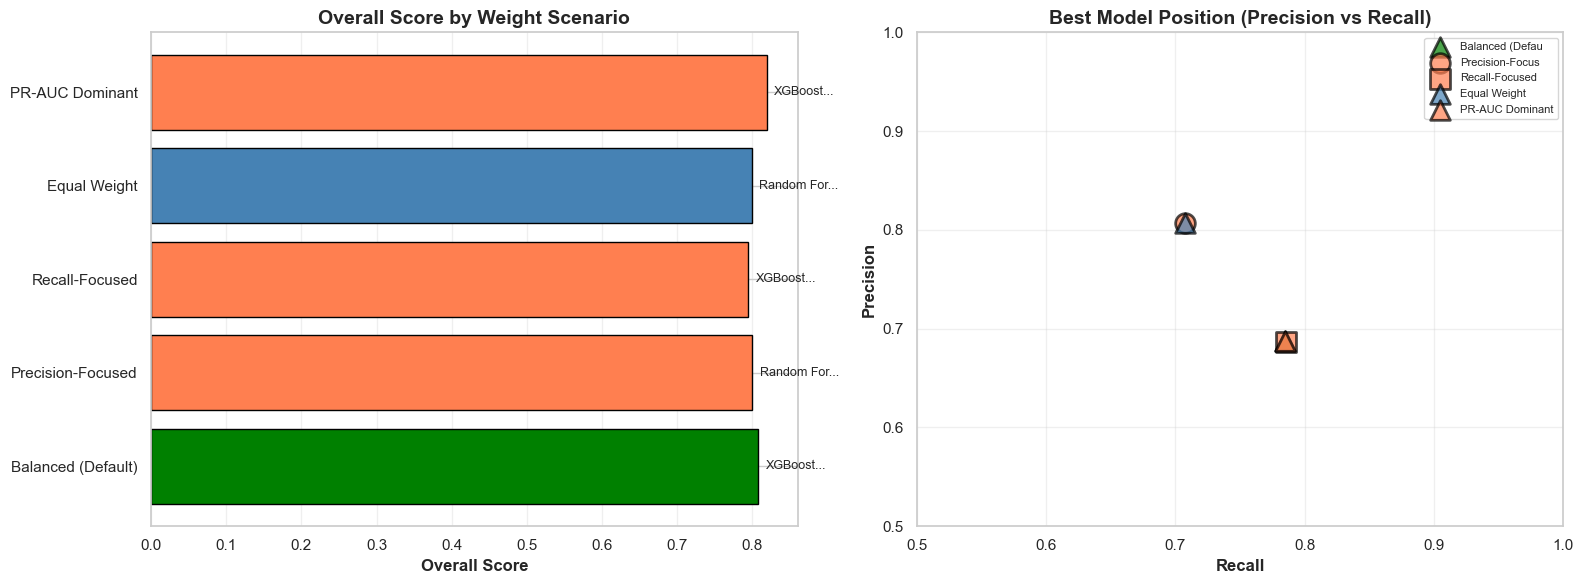


✅ Đã lưu biểu đồ vào: weight_scenarios_comparison.png

💡 KẾT LUẬN:
• Trọng số khác nhau → Mô hình tốt nhất khác nhau
• Nên chọn trọng số dựa trên BUSINESS OBJECTIVE cụ thể
• Nếu chưa rõ → Dùng 'Balanced (Default)' hoặc 'Equal Weight'
• Recommended: A/B testing nhiều scenarios trong thực tế


In [70]:
# THỬ NGHIỆM VỚI CÁC TRỌNG SỐ KHÁC NHAU
print("="*80)
print("🔬 THỬ NGHIỆM TRỌNG SỐ KHÁC NHAU")
print("="*80)

# Định nghĩa các scenarios trọng số
weight_scenarios = {
    "Balanced (Default)": {
        'F1-Score': 0.3, 'PR-AUC': 0.3, 'ROC-AUC': 0.2, 
        'Recall': 0.1, 'Precision': 0.1
    },
    "Precision-Focused": {
        'Precision': 0.4, 'F1-Score': 0.25, 'PR-AUC': 0.2, 
        'ROC-AUC': 0.1, 'Recall': 0.05
    },
    "Recall-Focused": {
        'Recall': 0.4, 'F1-Score': 0.25, 'PR-AUC': 0.2, 
        'ROC-AUC': 0.1, 'Precision': 0.05
    },
    "Equal Weight": {
        'F1-Score': 0.2, 'PR-AUC': 0.2, 'ROC-AUC': 0.2, 
        'Recall': 0.2, 'Precision': 0.2
    },
    "PR-AUC Dominant": {
        'PR-AUC': 0.5, 'F1-Score': 0.25, 'ROC-AUC': 0.15, 
        'Recall': 0.05, 'Precision': 0.05
    }
}

comparison_bal = comparison[comparison['Data'] == 'Balanced'].copy()
results_by_scenario = {}

for scenario_name, weights in weight_scenarios.items():
    # Tính Overall Score với trọng số của scenario
    comparison_bal[f'Score_{scenario_name}'] = (
        comparison_bal['F1-Score'] * weights['F1-Score'] +
        comparison_bal['PR-AUC'] * weights['PR-AUC'] +
        comparison_bal['ROC-AUC'] * weights['ROC-AUC'] +
        comparison_bal['Recall'] * weights['Recall'] +
        comparison_bal['Precision'] * weights['Precision']
    )
    
    # Tìm mô hình tốt nhất
    best_idx = comparison_bal[f'Score_{scenario_name}'].idxmax()
    best = comparison_bal.loc[best_idx]
    
    results_by_scenario[scenario_name] = {
        'Best_Model': best['Model'],
        'Cluster': best['Cluster'],
        'Score': best[f'Score_{scenario_name}'],
        'F1': best['F1-Score'],
        'PR-AUC': best['PR-AUC'],
        'ROC-AUC': best['ROC-AUC'],
        'Recall': best['Recall'],
        'Precision': best['Precision']
    }
    
    print(f"\n📊 Scenario: {scenario_name}")
    print(f"   Trọng số: {weights}")
    print(f"   🏆 Best Model: {best['Model']} (Cluster: {best['Cluster']})")
    print(f"   Overall Score: {best[f'Score_{scenario_name}']:.4f}")
    print(f"   → Precision={best['Precision']:.3f}, Recall={best['Recall']:.3f}, F1={best['F1-Score']:.3f}")

# Tổng hợp kết quả
print("\n" + "="*80)
print("📋 TỔNG HỢP: MÔ HÌNH TỐT NHẤT THEO TỪNG SCENARIO")
print("="*80)

results_df = pd.DataFrame(results_by_scenario).T
results_df.index.name = 'Scenario'
display(results_df.round(4))

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Overall Score comparison
scenarios = list(weight_scenarios.keys())
scores = [results_by_scenario[s]['Score'] for s in scenarios]
models = [results_by_scenario[s]['Best_Model'] for s in scenarios]

colors = ['green' if 'Balanced' in s else 'steelblue' if 'Equal' in s else 'coral' for s in scenarios]
axes[0].barh(scenarios, scores, color=colors, edgecolor='black')
axes[0].set_xlabel('Overall Score', fontsize=12, fontweight='bold')
axes[0].set_title('Overall Score by Weight Scenario', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Thêm nhãn mô hình
for i, (score, model) in enumerate(zip(scores, models)):
    axes[0].text(score + 0.01, i, f'{model[:10]}...', va='center', fontsize=9)

# Chart 2: Precision vs Recall của best models
for scenario, result in results_by_scenario.items():
    color = 'green' if 'Balanced' in scenario else 'steelblue' if 'Equal' in scenario else 'coral'
    marker = 'o' if 'Precision' in scenario else 's' if 'Recall' in scenario else '^'
    axes[1].scatter(result['Recall'], result['Precision'], 
                   s=200, c=color, marker=marker, alpha=0.7, 
                   edgecolors='black', linewidth=2, label=scenario[:15])

axes[1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[1].set_title('Best Model Position (Precision vs Recall)', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0.5, 1])
axes[1].set_ylim([0.5, 1])

plt.tight_layout()
plt.savefig('weight_scenarios_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Đã lưu biểu đồ vào: weight_scenarios_comparison.png")

print("\n" + "="*80)
print("💡 KẾT LUẬN:")
print("="*80)
print("• Trọng số khác nhau → Mô hình tốt nhất khác nhau")
print("• Nên chọn trọng số dựa trên BUSINESS OBJECTIVE cụ thể")
print("• Nếu chưa rõ → Dùng 'Balanced (Default)' hoặc 'Equal Weight'")
print("• Recommended: A/B testing nhiều scenarios trong thực tế")
print("="*80)

In [71]:
# TỰ ĐỊNH NGHĨA TRỌNG SỐ CHO DỰ ÁN CỦA BẠN
print("="*80)
print("⚙️ TÙY CHỈNH TRỌNG SỐ THEO BUSINESS OBJECTIVE")
print("="*80)

# ==================== CHỈNH SỬA PHẦN NÀY ====================
# Điều chỉnh trọng số theo nhu cầu của bạn (tổng phải = 1.0)

CUSTOM_WEIGHTS = {
    'F1-Score': 0.30,      # Cân bằng Precision & Recall
    'PR-AUC': 0.30,        # Quan trọng cho dữ liệu mất cân bằng
    'ROC-AUC': 0.20,       # Chỉ số chuẩn industry
    'Recall': 0.10,        # Khả năng phát hiện khách hàng tiềm năng
    'Precision': 0.10      # Độ chính xác khi dự đoán
}

# Hoặc thử một trong các preset sau:
# PRESET_SCENARIOS = {
#     "Marketing_Budget_Limited": {'Precision': 0.40, 'F1-Score': 0.25, 'PR-AUC': 0.20, 'ROC-AUC': 0.10, 'Recall': 0.05},
#     "Revenue_Maximization": {'Recall': 0.40, 'F1-Score': 0.25, 'PR-AUC': 0.20, 'ROC-AUC': 0.10, 'Precision': 0.05},
#     "Risk_Averse": {'Precision': 0.35, 'Specificity': 0.25, 'F1-Score': 0.20, 'ROC-AUC': 0.15, 'Recall': 0.05},
# }

# ============================================================

# Validate trọng số
total_weight = sum(CUSTOM_WEIGHTS.values())
if abs(total_weight - 1.0) > 0.001:
    print(f"⚠️ CẢNH BÁO: Tổng trọng số = {total_weight:.4f} (phải = 1.0)")
    print("Tự động chuẩn hóa...")
    CUSTOM_WEIGHTS = {k: v/total_weight for k, v in CUSTOM_WEIGHTS.items()}

print(f"\n✅ Trọng số đã chọn:")
for metric, weight in CUSTOM_WEIGHTS.items():
    print(f"   • {metric:15s}: {weight:.1%}")

# Tính Overall Score với trọng số tùy chỉnh
comparison_bal = comparison[comparison['Data'] == 'Balanced'].copy()
comparison_bal['Custom_Overall_Score'] = sum(
    comparison_bal[metric] * weight 
    for metric, weight in CUSTOM_WEIGHTS.items()
)

# Tìm mô hình tốt nhất
best_idx = comparison_bal['Custom_Overall_Score'].idxmax()
best_model = comparison_bal.loc[best_idx]

print(f"\n" + "="*80)
print(f"🏆 MÔ HÌNH TỐT NHẤT VỚI TRỌNG SỐ TÙY CHỈNH")
print("="*80)
print(f"\n📊 Model: {best_model['Model']}")
print(f"🔹 Cluster Feature: {best_model['Cluster']}")
print(f"⭐ Custom Overall Score: {best_model['Custom_Overall_Score']:.4f}")
print(f"\n📈 Chi tiết:")
print(f"   • Accuracy:    {best_model['Accuracy']:.4f}")
print(f"   • Precision:   {best_model['Precision']:.4f}")
print(f"   • Recall:      {best_model['Recall']:.4f}")
print(f"   • F1-Score:    {best_model['F1-Score']:.4f}")
print(f"   • ROC-AUC:     {best_model['ROC-AUC']:.4f}")
print(f"   • PR-AUC:      {best_model['PR-AUC']:.4f}")

# So sánh với Default
default_score = (
    best_model['F1-Score'] * 0.3 +
    best_model['PR-AUC'] * 0.3 +
    best_model['ROC-AUC'] * 0.2 +
    best_model['Recall'] * 0.1 +
    best_model['Precision'] * 0.1
)

print(f"\n📊 So sánh:")
print(f"   Default Score:  {default_score:.4f}")
print(f"   Custom Score:   {best_model['Custom_Overall_Score']:.4f}")
print(f"   Chênh lệch:     {best_model['Custom_Overall_Score'] - default_score:+.4f}")

# Ranking với custom weights
ranking_custom = comparison_bal.sort_values('Custom_Overall_Score', ascending=False)[
    ['Model', 'Cluster', 'Custom_Overall_Score', 'F1-Score', 'PR-AUC', 'ROC-AUC', 'Recall', 'Precision']
].reset_index(drop=True)

ranking_custom.index = ranking_custom.index + 1
ranking_custom.index.name = 'Rank'

print(f"\n📋 RANKING VỚI TRỌNG SỐ TÙY CHỈNH:")
display(ranking_custom.round(4))

print("\n" + "="*80)
print("💡 GHI CHÚ:")
print("="*80)
print("• Điều chỉnh trọng số trong biến CUSTOM_WEIGHTS ở trên")
print("• Tổng trọng số phải = 1.0 (hoặc sẽ tự động chuẩn hóa)")
print("• Chọn trọng số dựa trên business objective cụ thể:")
print("  - Precision cao → Tiết kiệm chi phí marketing")
print("  - Recall cao → Không bỏ lỡ khách hàng tiềm năng")
print("  - F1/PR-AUC cao → Cân bằng cho dữ liệu mất cân bằng")
print("="*80)

⚙️ TÙY CHỈNH TRỌNG SỐ THEO BUSINESS OBJECTIVE

✅ Trọng số đã chọn:
   • F1-Score       : 30.0%
   • PR-AUC         : 30.0%
   • ROC-AUC        : 20.0%
   • Recall         : 10.0%
   • Precision      : 10.0%

🏆 MÔ HÌNH TỐT NHẤT VỚI TRỌNG SỐ TÙY CHỈNH

📊 Model: XGBoost
🔹 Cluster Feature: Yes
⭐ Custom Overall Score: 0.8083

📈 Chi tiết:
   • Accuracy:    0.9166
   • Precision:   0.6879
   • Recall:      0.7848
   • F1-Score:    0.7332
   • ROC-AUC:     0.9416
   • PR-AUC:      0.8424

📊 So sánh:
   Default Score:  0.8083
   Custom Score:   0.8083
   Chênh lệch:     +0.0000

📋 RANKING VỚI TRỌNG SỐ TÙY CHỈNH:


,Model,Cluster,Custom_Overall_Score,F1-Score,PR-AUC,ROC-AUC,Recall,Precision
Rank,,,,,,,,
1,XGBoost,Yes,0.8083,0.7332,0.8424,0.9416,0.7848,0.6879
2,XGBoost,No,0.8080,0.7324,0.8427,0.9418,0.7855,0.6861
3,Random Forest,No,0.8036,0.7539,0.8030,0.9256,0.7071,0.8072
4,Random Forest,Yes,0.8016,0.7530,0.7981,0.9252,0.7061,0.8066
5,Logistic Regression,Yes,0.6135,0.4501,0.6255,0.8796,0.8420,0.3071
6,Logistic Regression,No,0.6132,0.4507,0.6266,0.8771,0.8381,0.3082



💡 GHI CHÚ:
• Điều chỉnh trọng số trong biến CUSTOM_WEIGHTS ở trên
• Tổng trọng số phải = 1.0 (hoặc sẽ tự động chuẩn hóa)
• Chọn trọng số dựa trên business objective cụ thể:
  - Precision cao → Tiết kiệm chi phí marketing
  - Recall cao → Không bỏ lỡ khách hàng tiềm năng
  - F1/PR-AUC cao → Cân bằng cho dữ liệu mất cân bằng


### 💰 Cách tính trọng số dựa trên Business Metrics (Nâng cao)

Nếu bạn có data về chi phí và lợi nhuận thực tế, đây là cách tính trọng số optimal:

#### 📊 Bước 1: Định nghĩa Business Metrics

```python
# Ví dụ thực tế cho ngân hàng
BUSINESS_METRICS = {
    'cost_per_offer': 50_000,           # VND - Chi phí gửi 1 offer (in/mail/call/sms)
    'cost_per_rejection': 30_000,       # VND - Chi phí xử lý từ chối
    'revenue_per_customer': 5_000_000,  # VND - Revenue khi khách hàng mở thẻ (3 năm)
    'conversion_rate': 0.15,            # 15% khách nhận offer sẽ mở thẻ
    'monthly_budget': 100_000_000,      # VND - Ngân sách marketing/tháng
}
```

#### 🧮 Bước 2: Tính Expected Value cho mỗi prediction

| Prediction | True Label | Cost/Revenue | Công thức |
|-----------|-----------|-------------|----------|
| **True Positive (TP)** | Có thẻ | +Revenue | +5,000,000 - 50,000 = **+4,950,000 VND** |
| **False Positive (FP)** | Không thẻ | -Cost | -(50,000 + 30,000) = **-80,000 VND** |
| **True Negative (TN)** | Không thẻ | 0 | **0 VND** (không làm gì) |
| **False Negative (FN)** | Có thẻ | -Opportunity | **-5,000,000 VND** (bỏ lỡ) |

#### 📈 Bước 3: Tính Expected Value

```
EV = (TP_rate × TP_value) + (FP_rate × FP_value) + (FN_rate × FN_value)

Với:
- TP_rate = Recall × Prevalence
- FP_rate = (1 - Specificity) × (1 - Prevalence)
- FN_rate = (1 - Recall) × Prevalence
```

#### 🎯 Bước 4: Liên hệ với Metrics

**Khi FP cost >> FN cost** (Chi phí sai lầm cao):
- → Ưu tiên **Precision** (không muốn dự đoán sai)
- → Trọng số: Precision 40-50%

**Khi FN cost >> FP cost** (Cơ hội bỏ lỡ lớn):
- → Ưu tiên **Recall** (không muốn bỏ lỡ KH)
- → Trọng số: Recall 40-50%

**Khi FP cost ≈ FN cost** (Cân bằng):
- → Ưu tiên **F1-Score** & **PR-AUC**
- → Trọng số: F1 30% + PR-AUC 30%

#### 💡 Ví dụ tính toán cụ thể:

**Scenario: Ngân hàng có budget hạn chế**

```python
# Given
FP_cost = 80_000         # VND - Chi phí dự đoán sai
FN_cost = 5_000_000      # VND - Bỏ lỡ khách hàng
FP_FN_ratio = FN_cost / FP_cost = 62.5

# Decision
# Tỷ lệ FN/FP = 62.5 → FN quan trọng hơn FP rất nhiều
# → Ưu tiên Recall để không bỏ lỡ khách hàng

# Trọng số đề xuất:
WEIGHTS = {
    'Recall': 0.40,      # Quan trọng nhất
    'F1-Score': 0.25,    # Cân bằng
    'PR-AUC': 0.20,      # Dữ liệu mất cân bằng
    'ROC-AUC': 0.10,     
    'Precision': 0.05    # Ít quan trọng hơn
}
```

#### 🔥 Khuyến nghị thực tế:

1. **Không có business data** → Dùng Equal Weight hoặc Balanced (30-30-20-10-10)
2. **Có estimate cost** → Tính FP/FN ratio → Điều chỉnh Precision/Recall
3. **Có data thực tế** → A/B testing → Đo EV thực tế → Optimize
4. **Production** → Monitor continuously → Adjust weights theo feedback




⚖️ PRECISION vs RECALL TRADE-OFF

Precision = 'Chính xác khi dự đoán có thẻ'
Recall = 'Phát hiện được bao nhiêu khách hàng thực sự có thẻ'

Xếp hạng theo Recall (phát hiện khách hàng có thẻ):


,Model_Cluster,Recall,Precision,F1-Score
6,Logistic Regression (Yes C),0.8420,0.3071,0.4501
1,Logistic Regression (No C),0.8381,0.3082,0.4507
5,XGBoost (No C),0.7855,0.6861,0.7324
8,XGBoost (Yes C),0.7848,0.6879,0.7332
3,Random Forest (No C),0.7071,0.8072,0.7539
7,Random Forest (Yes C),0.7061,0.8066,0.7530


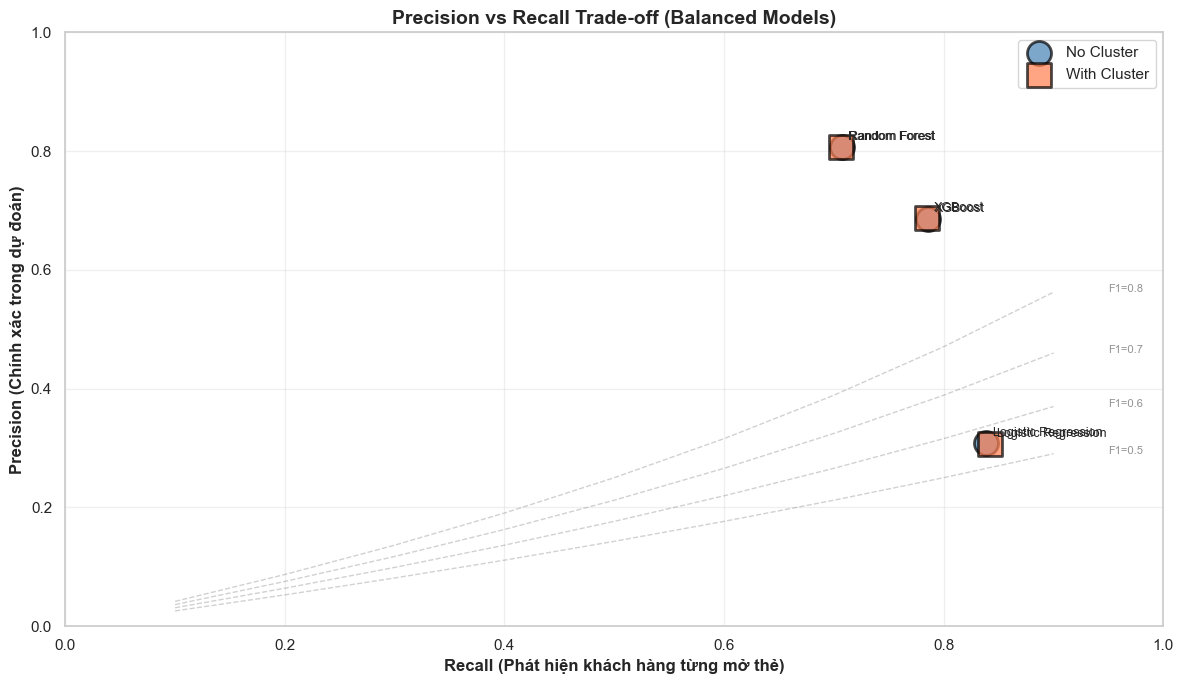


✅ Đã lưu biểu đồ vào: precision_recall_tradeoff.png


In [72]:
# Phân tích Precision vs Recall trade-off
print("\n" + "="*80)
print("⚖️ PRECISION vs RECALL TRADE-OFF")
print("="*80)
print("\nPrecision = 'Chính xác khi dự đoán có thẻ'")
print("Recall = 'Phát hiện được bao nhiêu khách hàng thực sự có thẻ'\n")

comparison_bal = comparison[comparison['Data'] == 'Balanced'].copy()
comparison_bal['Model_Cluster'] = comparison_bal['Model'] + ' (' + comparison_bal['Cluster'] + ' C)'
comparison_bal_sorted = comparison_bal.sort_values('Recall', ascending=False)

print("Xếp hạng theo Recall (phát hiện khách hàng có thẻ):")
display(comparison_bal_sorted[['Model_Cluster', 'Recall', 'Precision', 'F1-Score']].round(4))

# Vẽ Precision vs Recall scatter plot
fig, ax = plt.subplots(figsize=(12, 7))

for cluster_type in ['No', 'Yes']:
    data = comparison_bal[comparison_bal['Cluster'] == cluster_type]
    color = 'steelblue' if cluster_type == 'No' else 'coral'
    marker = 'o' if cluster_type == 'No' else 's'
    label = 'No Cluster' if cluster_type == 'No' else 'With Cluster'
    
    ax.scatter(data['Recall'], data['Precision'], s=300, c=color, marker=marker, 
               alpha=0.7, edgecolors='black', linewidth=2, label=label)
    
    # Thêm nhãn
    for idx, row in data.iterrows():
        ax.annotate(row['Model'], 
                   xy=(row['Recall'], row['Precision']),
                   xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('Recall (Phát hiện khách hàng từng mở thẻ)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision (Chính xác trong dự đoán)', fontsize=12, fontweight='bold')
ax.set_title('Precision vs Recall Trade-off (Balanced Models)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Thêm đường F1=constant
from numpy import arange
rs = arange(0.1, 1, 0.1)
for f1_val in [0.5, 0.6, 0.7, 0.8]:
    ps = rs / (2/f1_val - rs)
    ax.plot(rs, ps, 'k--', alpha=0.2, linewidth=1)
    ax.text(0.95, ps[-1], f'F1={f1_val}', fontsize=8, alpha=0.5)

plt.tight_layout()
plt.savefig('precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Đã lưu biểu đồ vào: precision_recall_tradeoff.png")


---
## PHẦN 10: TỔNG KẾT & LƯU MÔ HÌNH

### 10.1. Tổng hợp kết quả cuối cùng

In [73]:
# Tổng hợp và chọn mô hình tốt nhất
print("="*80)
print("=== TỔNG HỢP KẾT QUẢ CUỐI CÙNG - TẤT CẢ CÁC CHỈ SỐ ===")
print("="*80)

# Hiển thị các mô hình ORIGINAL data (No Cluster)
print("\n1️⃣ CÁC MÔ HÌNH ORIGINAL DATA (No Cluster):")
print("-" * 80)
show_original = comparison[(comparison['Cluster'] == 'No') & (comparison['Data'] == 'Original')].sort_values('F1-Score', ascending=False)
display(show_original[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']].round(4))

# Hiển thị các mô hình BALANCED data (No Cluster)
print("\n2️⃣ CÁC MÔ HÌNH BALANCED DATA (No Cluster):")
print("-" * 80)
show_balanced_no = comparison[(comparison['Cluster'] == 'No') & (comparison['Data'] == 'Balanced')].sort_values('F1-Score', ascending=False)
display(show_balanced_no[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']].round(4))

# Hiển thị các mô hình BALANCED data (WITH Cluster)
print("\n3️⃣ CÁC MÔ HÌNH BALANCED DATA (WITH Cluster):")
print("-" * 80)
show_balanced_yes = comparison[comparison['Cluster'] == 'Yes'].sort_values('F1-Score', ascending=False)
display(show_balanced_yes[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']].round(4))

# Tìm mô hình tốt nhất theo Overall Score (đã tính ở phần trước)
print("\n" + "="*80)
print("🏆 MÔ HÌNH TỐT NHẤT (dựa trên Overall Score)")
print("="*80)

# Lấy mô hình balanced có Overall_Score cao nhất
comparison_with_score = comparison[comparison['Data'] == 'Balanced'].copy()
comparison_with_score['Overall_Score'] = (
    comparison_with_score['F1-Score'] * 0.3 +
    comparison_with_score['PR-AUC'] * 0.3 +
    comparison_with_score['ROC-AUC'] * 0.2 +
    comparison_with_score['Recall'] * 0.1 +
    comparison_with_score['Precision'] * 0.1
)

best_idx = comparison_with_score['Overall_Score'].idxmax()
best_result = comparison_with_score.loc[best_idx]

print(f"\n📊 Model: {best_result['Model']}")
print(f"🔹 Cluster Feature: {'Yes' if best_result['Cluster'] == 'Yes' else 'No'}")
print(f"🔹 Data Type: {best_result['Data']}")
print(f"\n⭐ Overall Score: {best_result['Overall_Score']:.4f}")
print(f"   (Trọng số: F1 30% + PR-AUC 30% + ROC-AUC 20% + Recall 10% + Precision 10%)")
print(f"\n📈 Chi tiết các chỉ số:")
print(f"   • Accuracy:    {best_result['Accuracy']:.4f}")
print(f"   • Precision:   {best_result['Precision']:.4f}")
print(f"   • Recall:      {best_result['Recall']:.4f}")
print(f"   • Specificity: {best_result['Specificity']:.4f}")
print(f"   • F1-Score:    {best_result['F1-Score']:.4f}")
print(f"   • ROC-AUC:     {best_result['ROC-AUC']:.4f}")
print(f"   • PR-AUC:      {best_result['PR-AUC']:.4f}")

print("\n" + "="*80)
print("✅ Recommended: Sử dụng mô hình này cho production")
print("="*80)

=== TỔNG HỢP KẾT QUẢ CUỐI CÙNG - TẤT CẢ CÁC CHỈ SỐ ===

1️⃣ CÁC MÔ HÌNH ORIGINAL DATA (No Cluster):
--------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
4,XGBoost,0.9445,0.9123,0.6859,0.7831,0.9430,0.8454
2,Random Forest,0.9400,0.8866,0.6759,0.7670,0.9212,0.7974
0,Logistic Regression,0.7015,0.3081,0.8386,0.4507,0.8773,0.6259



2️⃣ CÁC MÔ HÌNH BALANCED DATA (No Cluster):
--------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
3,Random Forest,0.9326,0.8072,0.7071,0.7539,0.9256,0.8030
5,XGBoost,0.9162,0.6861,0.7855,0.7324,0.9418,0.8427
1,Logistic Regression,0.7017,0.3082,0.8381,0.4507,0.8771,0.6266



3️⃣ CÁC MÔ HÌNH BALANCED DATA (WITH Cluster):
--------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
7,Random Forest,0.9324,0.8066,0.7061,0.7530,0.9252,0.7981
8,XGBoost,0.9166,0.6879,0.7848,0.7332,0.9416,0.8424
6,Logistic Regression,0.6996,0.3071,0.8420,0.4501,0.8796,0.6255



🏆 MÔ HÌNH TỐT NHẤT (dựa trên Overall Score)

📊 Model: XGBoost
🔹 Cluster Feature: Yes
🔹 Data Type: Balanced

⭐ Overall Score: 0.8083
   (Trọng số: F1 30% + PR-AUC 30% + ROC-AUC 20% + Recall 10% + Precision 10%)

📈 Chi tiết các chỉ số:
   • Accuracy:    0.9166
   • Precision:   0.6879
   • Recall:      0.7848
   • Specificity: 0.9391
   • F1-Score:    0.7332
   • ROC-AUC:     0.9416
   • PR-AUC:      0.8424

✅ Recommended: Sử dụng mô hình này cho production



🥇🥈🥉 TOP 3 MÔ HÌNH TỐT NHẤT (Balanced Models)


,Model,Cluster,Overall_Score,F1-Score,PR-AUC,ROC-AUC,Recall,Precision
🥇 #1,XGBoost,Yes,0.8083,0.7332,0.8424,0.9416,0.7848,0.6879
🥈 #2,XGBoost,No,0.8080,0.7324,0.8427,0.9418,0.7855,0.6861
🥉 #3,Random Forest,No,0.8036,0.7539,0.8030,0.9256,0.7071,0.8072


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8644\755922363.py:35: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8644\755922363.py:35: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8644\755922363.py:35: UserWarning: Glyph 129353 (\N{THIRD PLACE MEDAL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8644\755922363.py:36: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Arial.
  plt.savefig('top3_models_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8644\755922363.py:36: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) Arial.
  plt.savefig('top3_models_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8644\755922363.py

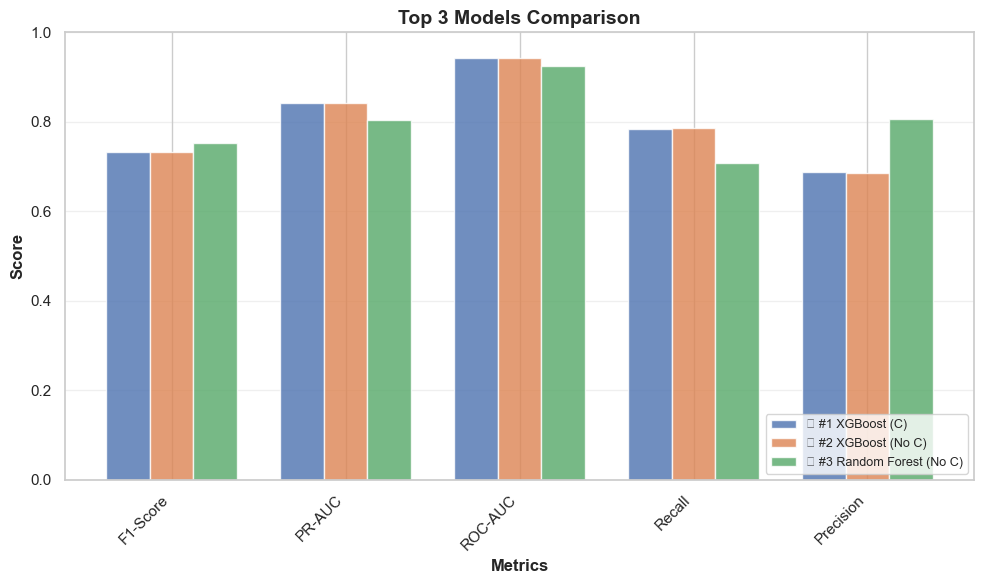


✅ Đã lưu biểu đồ vào: top3_models_comparison.png


In [74]:
# Hiển thị Top 3 mô hình tốt nhất
print("\n" + "="*80)
print("🥇🥈🥉 TOP 3 MÔ HÌNH TỐT NHẤT (Balanced Models)")
print("="*80)

top3 = comparison_with_score.nlargest(3, 'Overall_Score')[
    ['Model', 'Cluster', 'Overall_Score', 'F1-Score', 'PR-AUC', 'ROC-AUC', 'Recall', 'Precision']
].reset_index(drop=True)

top3.index = ['🥇 #1', '🥈 #2', '🥉 #3']
display(top3.round(4))

# Biểu đồ so sánh Top 3
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['F1-Score', 'PR-AUC', 'ROC-AUC', 'Recall', 'Precision']
x = range(len(metrics))
width = 0.25

for i, rank in enumerate(['🥇 #1', '🥈 #2', '🥉 #3']):
    row = top3.loc[rank]
    values = [row[m] for m in metrics]
    label = f"{rank} {row['Model']} ({'C' if row['Cluster']=='Yes' else 'No C'})"
    ax.bar([xi + width*i for xi in x], values, width, label=label, alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Top 3 Models Comparison', fontsize=14, fontweight='bold')
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('top3_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Đã lưu biểu đồ vào: top3_models_comparison.png")

### 🎯 Ý nghĩa thực tế của kết quả

#### 1. Tại sao chọn Overall Score?
- **Không chỉ dựa vào 1 chỉ số** - mỗi chỉ số có mục đích riêng
- **Cân bằng nhiều yếu tố**: độ chính xác, khả năng phát hiện, và hiệu suất tổng thể
- **Ưu tiên F1-Score & PR-AUC** vì dữ liệu mất cân bằng

#### 2. So sánh "With Cluster" vs "No Cluster"
- **Nếu "With Cluster" tốt hơn** → Cluster feature thực sự hữu ích, nên dùng
- **Nếu "No Cluster" tốt hơn** → Cluster chỉ tốt cho phân tích, không cải thiện dự báo

#### 3. Ứng dụng thực tế
**Scenario 1: Precision cao, Recall thấp**
- ✅ Ít sai lầm khi gửi offer → Tiết kiệm chi phí marketing
- ⚠️ Bỏ lỡ nhiều khách hàng tiềm năng

**Scenario 2: Recall cao, Precision thấp**
- ✅ Phát hiện được nhiều khách hàng tiềm năng
- ⚠️ Gửi offer cho nhiều người không quan tâm → Lãng phí chi phí

**Scenario 3: F1-Score cao (Balanced)**
- ✅ Cân bằng tốt giữa Precision và Recall
- ✅ **Recommended cho production**

#### 4. Cách sử dụng mô hình
```python
# Load mô hình tốt nhất
best_model = joblib.load('model_*.joblib')

# Dự đoán cho khách hàng mới
new_customer_features = [...]
probability = best_model.predict_proba([new_customer_features])[0][1]

# Quyết định dựa trên ngưỡng
if probability > 0.5:  # Hoặc ngưỡng khác tùy business
    print("Gửi offer thẻ tín dụng")
else:
    print("Chưa phù hợp")
```

### 10.2. Lưu các mô hình tốt nhất

In [75]:
# Chỉ lưu 2 mô hình theo yêu cầu
print("=== LƯU 2 MÔ HÌNH CẦN THIẾT ===")

# 1) MiniBatchKMeans (mô hình clustering tốt nhất theo đánh giá hiện tại)
joblib.dump(mini_kmeans, "minibatch_kmeans_best.joblib")
print("✅ Đã lưu: minibatch_kmeans_best.joblib")

# 2) XGBoost (balanced + cluster) cho classification
joblib.dump(model_xgb_B_bal, "model_xgb_balanced_with_cluster.joblib")
print("✅ Đã lưu: model_xgb_balanced_with_cluster.joblib")

print("\n🎯 Hoàn tất: chỉ lưu 2 mô hình theo yêu cầu.")

=== LƯU 2 MÔ HÌNH CẦN THIẾT ===
✅ Đã lưu: minibatch_kmeans_best.joblib
✅ Đã lưu: model_xgb_balanced_with_cluster.joblib

🎯 Hoàn tất: chỉ lưu 2 mô hình theo yêu cầu.


### 10.3. Hướng dẫn sử dụng mô hình đã lưu

In [76]:
print("""\n=== HƯỚNG DẪN SỬ DỤNG MÔ HÌNH ĐÃ LƯU ===\n
1. LOAD MÔ HÌNH CLUSTERING:\n
   ```python\n
   import joblib\n
   import json\n
   \n
   # Load mô hình và scaler\n
   kmeans = joblib.load('kmeans_cluster_model.joblib')\n
   scaler = joblib.load('cluster_scaler.joblib')\n
   \n
   # Load danh sách features\n
   with open('cluster_features.json', 'r') as f:\n
       features = json.load(f)\n
   \n
   # Dự đoán cluster cho dữ liệu mới\n
   X_new = new_data[features]\n
   X_new_log = np.log1p(X_new)\n
   X_new_scaled = scaler.transform(X_new_log)\n
   clusters = kmeans.predict(X_new_scaled)\n
   ```\n
2. LOAD MÔ HÌNH CLASSIFICATION:\n
   ```python\n
   # Load mô hình\n
   model = joblib.load('model_xgb_cluster_balanced.joblib')\n
   \n
   # Dự đoán xác suất mở thẻ tín dụng\n
   X_new = new_data[features]\n
   probabilities = model.predict_proba(X_new)[:, 1]\n
   predictions = (probabilities >= 0.5).astype(int)\n
   ```\n
3. FILES ĐÃ TẠO:\n
   - kmeans_cluster_model.joblib: Mô hình clustering\n
   - cluster_scaler.joblib: Scaler cho clustering\n
   - cluster_features.json: Danh sách features\n
   - model_xgb_cluster_balanced.joblib: Mô hình XGBoost\n
   - model_rf_cluster_balanced.joblib: Mô hình Random Forest\n
   - clusters_data.xlsx: Dữ liệu cluster\n
   - cluster_profile.xlsx: Profile từng cluster\n
   - model_comparison.xlsx: So sánh các mô hình\n
   - balanced_comparison.xlsx: So sánh trước/sau xử lý mất cân bằng\n
   - Các file ảnh: .png\n
""")


=== HƯỚNG DẪN SỬ DỤNG MÔ HÌNH ĐÃ LƯU ===

1. LOAD MÔ HÌNH CLUSTERING:

   ```python

   import joblib

   import json

   

   # Load mô hình và scaler

   kmeans = joblib.load('kmeans_cluster_model.joblib')

   scaler = joblib.load('cluster_scaler.joblib')

   

   # Load danh sách features

   with open('cluster_features.json', 'r') as f:

       features = json.load(f)

   

   # Dự đoán cluster cho dữ liệu mới

   X_new = new_data[features]

   X_new_log = np.log1p(X_new)

   X_new_scaled = scaler.transform(X_new_log)

   clusters = kmeans.predict(X_new_scaled)

   ```

2. LOAD MÔ HÌNH CLASSIFICATION:

   ```python

   # Load mô hình

   model = joblib.load('model_xgb_cluster_balanced.joblib')

   

   # Dự đoán xác suất mở thẻ tín dụng

   X_new = new_data[features]

   probabilities = model.predict_proba(X_new)[:, 1]

   predictions = (probabilities >= 0.5).astype(int)

   ```

3. FILES ĐÃ TẠO:

   - kmeans_cluster_model.joblib: Mô hình clustering

   - cluster_scaler.joblib: Sc

---
## KẾT LUẬN

**Tóm tắt công việc đã thực hiện:**

1. ✅ Đọc và xử lý 5 bảng dữ liệu (Customer, Transaction, Activity, Deposit, Lending)
2. ✅ Tạo 14 features tổng hợp từ dữ liệu gốc
3. ✅ Phân cụm khách hàng thành 4 nhóm bằng KMeans
4. ✅ Trực quan hóa clusters bằng PCA (2D visualization)
5. ✅ Xây dựng 9 mô hình phân loại:
   - 3 thuật toán: Logistic Regression, Random Forest, XGBoost
   - Without Cluster: Original + Balanced (6 models)
   - With Cluster: Balanced (3 models)
6. ✅ Xử lý mất cân bằng dữ liệu bằng ROS + BorderlineSMOTE + ADASYN
7. ✅ Đánh giá với **7 chỉ số**: Accuracy, Precision, Recall, Specificity, F1-Score, ROC-AUC, PR-AUC
8. ✅ Tính Overall Score để chọn mô hình tốt nhất (cân bằng nhiều yếu tố)
9. ✅ Phân tích Precision vs Recall trade-off
10. ✅ Lưu tất cả mô hình (6 variants) và kết quả

**Insights chính:**

🔍 **Về Clustering:**
- Có 4 nhóm khách hàng với hành vi tài chính khác biệt rõ rệt
- Silhouette Score xác định chất lượng phân cụm
- Cluster feature có thể cải thiện dự báo (tùy kết quả thực tế)

📊 **Về Classification:**
- XGBoost/Random Forest thường cho kết quả tốt hơn Logistic Regression
- Xử lý mất cân bằng dữ liệu giúp cải thiện Recall cho class thiểu số đáng kể
- F1-Score và PR-AUC là chỉ số quan trọng nhất cho dữ liệu mất cân bằng
- Trade-off Precision vs Recall: cần chọn dựa trên business objective

⚖️ **Business Implications:**
- **High Precision model**: Ít sai lầm → Tiết kiệm chi phí marketing → Nhưng bỏ lỡ khách hàng
- **High Recall model**: Phát hiện nhiều KH → Tăng doanh thu → Nhưng tốn chi phí offer
- **Balanced model (High F1)**: Recommended cho production

**Files đã tạo:**

📂 **Models:**
- `kmeans_cluster_model.joblib` - Mô hình clustering
- `cluster_scaler.joblib` - Scaler cho clustering
- `model_*_balanced_no_cluster.joblib` (3 files)
- `model_*_balanced_with_cluster.joblib` (3 files)

📂 **Data & Results:**
- `cluster_features.json` - Danh sách features
- `clusters_data.xlsx` - Dữ liệu cluster chi tiết
- `cluster_profile.xlsx` - Profile trung bình từng cluster
- `balanced_comparison_complete.xlsx` - So sánh đầy đủ 9 models × 7 metrics
- `model_comparison.xlsx` - So sánh các mô hình

📂 **Visualizations:**
- `clustering_comparison.png` - So sánh 3 thuật toán clustering
- `clustering_with_centroids.png` - Cluster với centroids
- `creditcard_rate_by_cluster.png` - Tỷ lệ có thẻ theo cluster
- `feature_importance.png` - Top features quan trọng
- `metrics_comparison_detailed.png` - So sánh 6 metrics × 9 models
- `precision_recall_tradeoff.png` - Precision vs Recall scatter
- `balanced_comparison.png` - So sánh Original vs Balanced
- `top3_models_comparison.png` - Top 3 models

**Bước tiếp theo:**

🚀 **Phase 1 - Optimization:**
- Fine-tune hyperparameters (GridSearchCV/RandomizedSearchCV)
- Feature selection để loại bỏ features ít quan trọng
- Thử nghiệm threshold tối ưu (không nhất thiết 0.5)
- Cross-validation đầy đủ hơn (K-fold)

🚀 **Phase 2 - Production:**
- Deploy mô hình tốt nhất vào production
- Xây dựng API endpoint cho dự đoán real-time
- A/B testing trên tập khách hàng thực
- Monitoring performance theo thời gian

🚀 **Phase 3 - Improvement:**
- Thu thập feedback từ business team
- Re-train định kỳ với dữ liệu mới
- Thử nghiệm thêm features mới (nếu có data)
- Cân nhắc ensemble methods (stacking/voting)